In [ ]:
!pip install -U -q peft transformers accelerate safetensors

import os, gc, json, time, zipfile, math, warnings
from dataclasses import dataclass, asdict
from pathlib import Path
from typing import Dict, List, Optional, Tuple, Any

import numpy as np
import pandas as pd
from PIL import Image
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, Sampler
import torchvision.transforms as T

from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import average_precision_score

warnings.filterwarnings("ignore", category=UserWarning)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("DEVICE:", DEVICE)
if DEVICE.type == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))
    torch.set_float32_matmul_precision("high")

from google.colab import drive
drive.mount('/content/drive')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.6/11.6 MB 57.7 MB/s eta 0:00:00
DEVICE: cuda
GPU: Tesla T4
Mounted at /content/drive


In [ ]:
@dataclass
class CFGType:
    drive_root: str = "/content/drive/MyDrive"          # zip lives directly in MyDrive on this account
    zip_name: str = "ePillID_data.zip"
    extract_dir: str = "/content/extracted"
    data_root: str = ""

    dinov2_model_id: str = "facebook/dinov2-large"
    dinov2_model_key: str = "dinov2_large"

    num_workers: int = 0
    pin_memory: bool = False

    topk: Tuple[int, ...] = (1, 3, 5, 10, 20, 50)
    score_chunk_size: int = 256
    sidepair_aggs: Tuple[str, ...] = ("mean", "max")

    feature_batch_size: int = 48

    proj_embedding_dim: int = 512
    proj_hidden_dim: int = 1024

    seed: int = 42

CFG = CFGType()
DRIVE_ROOT = Path(CFG.drive_root)
ZIP_PATH = DRIVE_ROOT / CFG.zip_name
EXTRACT_DIR = Path(CFG.extract_dir)

# --- Run folders copied over from your old account's Drive ---
RUN_DIR_MAIN = DRIVE_ROOT / "ePillID_dinov2_adaptation_results" / "epillid_dinov2_fusion_finetune_lora_20260709_233943"
RUN_DIR_AUGHEAD = DRIVE_ROOT / "ePillID_dinov2_adaptation_results" / "epillid_dinov2_fusion_finetune_lora_20260708_234614"

AUG_HEAD_CKPT = RUN_DIR_AUGHEAD / "augmented_projection_head_200ep" / "best_projection_head.pt"
LORA_HEAD_CKPT = RUN_DIR_MAIN / "lora_fine_tuned_backbone" / "best_lora_head.pt"

# Feature cache paths — 224px (original) and 448px TTA (new, used for the accuracy boosters)
REF_FEAT_224_PATH = RUN_DIR_MAIN / "feature_cache" / f"{CFG.dinov2_model_key}_ref_features.pt"
REF_FEAT_448_PATH = RUN_DIR_MAIN / "persistent_aug_feature_cache" / "ref_feat_448_tta.pt"          # NEW, will be generated
TEST_FEAT_448_PATH = RUN_DIR_MAIN / "persistent_aug_feature_cache" / "test_feat_448_tta.pt"          # NEW, will be generated
VAL_FEAT_448_PATH = RUN_DIR_MAIN / "persistent_aug_feature_cache" / "val_feat_448_tta.pt"            # NEW, will be generated

for label, p in [
    ("ZIP_PATH", ZIP_PATH),
    ("AUG_HEAD_CKPT", AUG_HEAD_CKPT),
    ("LORA_HEAD_CKPT", LORA_HEAD_CKPT),
    ("REF_FEAT_224_PATH", REF_FEAT_224_PATH),
]:
    print(f"{label}: {p}  --  {'FOUND' if p.exists() else 'MISSING'}")


ZIP_PATH: /content/drive/MyDrive/ePillID_data.zip  --  FOUND
AUG_HEAD_CKPT: /content/drive/MyDrive/ePillID_dinov2_adaptation_results/epillid_dinov2_fusion_finetune_lora_20260708_234614/augmented_projection_head_200ep/best_projection_head.pt  --  FOUND
LORA_HEAD_CKPT: /content/drive/MyDrive/ePillID_dinov2_adaptation_results/epillid_dinov2_fusion_finetune_lora_20260709_233943/lora_fine_tuned_backbone/best_lora_head.pt  --  FOUND
REF_FEAT_224_PATH: /content/drive/MyDrive/ePillID_dinov2_adaptation_results/epillid_dinov2_fusion_finetune_lora_20260709_233943/feature_cache/dinov2_large_ref_features.pt  --  FOUND


In [ ]:
def seed_everything(seed: int = 42):
    import random
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

seed_everything(CFG.seed)

def cleanup_cuda():
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

In [ ]:
EXTRACT_DIR.mkdir(parents=True, exist_ok=True)

def is_dir_empty(p: Path) -> bool:
    return not any(p.iterdir())

if is_dir_empty(EXTRACT_DIR):
    assert ZIP_PATH.exists(), f"Zip not found at {ZIP_PATH}"
    print(f"Extracting {ZIP_PATH} -> {EXTRACT_DIR} ...")
    with zipfile.ZipFile(ZIP_PATH, "r") as zf:
        zf.extractall(EXTRACT_DIR)
    print("Done.")
else:
    print("EXTRACT_DIR not empty, skipping extraction.")

def find_epillid_data_root(extract_dir: Path) -> Path:
    if CFG.data_root:
        p = Path(CFG.data_root)
        assert (p / "classification_data").exists(), p
        assert (p / "folds").exists(), p
        return p
    candidates = []
    for classif_dir in extract_dir.rglob("classification_data"):
        root = classif_dir.parent
        if (root / "folds").exists():
            candidates.append(root)
    if not candidates and (extract_dir / "classification_data").exists() and (extract_dir / "folds").exists():
        candidates.append(extract_dir)
    if not candidates:
        raise FileNotFoundError(f"Could not find classification_data/ and folds/ under {extract_dir}")
    return sorted(candidates, key=lambda p: len(str(p)))[0]

DATA_ROOT = find_epillid_data_root(EXTRACT_DIR)
CFG.data_root = str(DATA_ROOT)
print("DATA_ROOT:", DATA_ROOT)

def find_default_split_files(data_root: Path):
    folds_dir = data_root / "folds"
    all_csvs = sorted(folds_dir.rglob("*_all.csv"))
    if not all_csvs:
        raise FileNotFoundError(f"No *_all.csv files found under {folds_dir}")
    preferred = [p for p in all_csvs if "pilltypeid_nih_sidelbls0.01_metric_5folds" in str(p)]
    all_csv = preferred[0] if preferred else all_csvs[0]
    base_dir = all_csv.parent
    stem = all_csv.name[:-len("_all.csv")]
    val_csv = base_dir / f"{stem}_3.csv"
    test_csv = base_dir / f"{stem}_4.csv"
    if not val_csv.exists() or not test_csv.exists():
        fold_csvs = sorted([p for p in base_dir.glob(f"{stem}_*.csv") if not p.name.endswith("_all.csv")])
        val_csv, test_csv = fold_csvs[-2], fold_csvs[-1]
    return all_csv, val_csv, test_csv

ALL_CSV, VAL_CSV, TEST_CSV = find_default_split_files(DATA_ROOT)
print("ALL_CSV:", ALL_CSV)
print("VAL_CSV:", VAL_CSV)
print("TEST_CSV:", TEST_CSV)

def to_bool_series(s: pd.Series) -> pd.Series:
    if s.dtype == bool:
        return s
    if pd.api.types.is_numeric_dtype(s):
        return s.astype(int).astype(bool)
    return s.astype(str).str.lower().map({
        "true": True, "false": False, "1": True, "0": False, "yes": True, "no": False,
    }).fillna(False).astype(bool)

def resolve_image_root(df: pd.DataFrame, data_root: Path, rel_col: str) -> Path:
    sample = df[rel_col].dropna().astype(str).head(200).tolist()
    roots = [data_root, data_root / "classification_data", data_root / "classification_data" / "fcn_mix_weight"]
    best_root, best_hits = None, -1
    for root in roots:
        hits = sum((root / rel).exists() for rel in sample)
        if hits > best_hits:
            best_root, best_hits = root, hits
    if best_root is None or best_hits == 0:
        image_files = {p.name: p for p in (data_root / "classification_data").rglob("*") if p.is_file()}
        hits = sum(Path(rel).name in image_files for rel in sample)
        if hits == 0:
            raise FileNotFoundError("Could not resolve image paths from CSV metadata.")
        return Path("__FILENAME_LOOKUP__")
    return best_root

def add_abs_paths(df: pd.DataFrame, data_root: Path) -> pd.DataFrame:
    df = df.copy()
    rel_col = "image_path" if "image_path" in df.columns else "images"
    root = resolve_image_root(df, data_root, rel_col)
    if str(root) == "__FILENAME_LOOKUP__":
        image_files = {p.name: p for p in (data_root / "classification_data").rglob("*") if p.is_file()}
        df["abs_path"] = df[rel_col].astype(str).map(lambda x: str(image_files.get(Path(x).name, "")))
    else:
        df["abs_path"] = df[rel_col].astype(str).map(lambda x: str(root / x))
    df["rel_key"] = df[rel_col].astype(str)
    return df

def prepare_df(csv_path: Path, data_root: Path) -> pd.DataFrame:
    df = pd.read_csv(csv_path)
    df = add_abs_paths(df, data_root)
    df["is_ref"] = to_bool_series(df["is_ref"])
    df["is_front"] = to_bool_series(df["is_front"]) if "is_front" in df.columns else True
    return df

all_df = prepare_df(ALL_CSV, DATA_ROOT)
val_df = prepare_df(VAL_CSV, DATA_ROOT)
test_df = prepare_df(TEST_CSV, DATA_ROOT)

label_candidates = ["label", "pilltype_id", "label_prod_code", "product_code"]
LABEL_COL = next((c for c in label_candidates if c in all_df.columns), None)

val_keys = set(val_df["rel_key"])
test_keys = set(test_df["rel_key"])
train_df = all_df[~all_df["rel_key"].isin(val_keys | test_keys)].copy()

ref_df = train_df[train_df["is_ref"]].copy()
val_query_df = val_df[~val_df["is_ref"]].copy()
test_query_df = test_df[~test_df["is_ref"]].copy()
if len(val_query_df) == 0: val_query_df = val_df.copy()
if len(test_query_df) == 0: test_query_df = test_df.copy()

label_encoder = LabelEncoder()
label_encoder.fit(all_df[LABEL_COL].astype(str))

def add_label_indexes(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    df["label_str"] = df[LABEL_COL].astype(str)
    df["label_idx"] = label_encoder.transform(df["label_str"])
    return df

ref_df = add_label_indexes(ref_df)
val_query_df = add_label_indexes(val_query_df)
test_query_df = add_label_indexes(test_query_df)

N_CLASSES = len(label_encoder.classes_)
print("N_CLASSES:", N_CLASSES)
print("ref_df:", ref_df.shape, "val_query_df:", val_query_df.shape, "test_query_df:", test_query_df.shape)

Extracting /content/drive/MyDrive/ePillID_data.zip -> /content/extracted ...
Done.
DATA_ROOT: /content/extracted/ePillID_data
ALL_CSV: /content/extracted/ePillID_data/folds/pilltypeid_nih_sidelbls0.01_metric_5folds/base/pilltypeid_nih_sidelbls0.01_metric_5folds_all.csv
VAL_CSV: /content/extracted/ePillID_data/folds/pilltypeid_nih_sidelbls0.01_metric_5folds/base/pilltypeid_nih_sidelbls0.01_metric_5folds_3.csv
TEST_CSV: /content/extracted/ePillID_data/folds/pilltypeid_nih_sidelbls0.01_metric_5folds/base/pilltypeid_nih_sidelbls0.01_metric_5folds_4.csv
N_CLASSES: 4902
ref_df: (9804, 13) val_query_df: (745, 13) test_query_df: (745, 13)


In [ ]:
def label_score_matrix(query_emb, ref_emb, ref_labels, num_classes, chunk_size=256, device=None):
    if device is None:
        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    ref_emb = F.normalize(ref_emb.to(device), dim=1)
    ref_labels = ref_labels.to(device).long()
    all_scores = []
    for start in tqdm(range(0, query_emb.shape[0], chunk_size), desc="Score queries", leave=False):
        q = F.normalize(query_emb[start:start + chunk_size].to(device), dim=1)
        sim = q @ ref_emb.T
        b = sim.shape[0]
        scores = torch.full((b, num_classes), -1e9, device=device)
        index = ref_labels.unsqueeze(0).expand(b, -1)
        if hasattr(scores, "scatter_reduce_"):
            scores.scatter_reduce_(1, index, sim, reduce="amax", include_self=True)
        else:
            for c in torch.unique(ref_labels):
                scores[:, int(c.item())] = sim[:, ref_labels == c].max(dim=1).values
        all_scores.append(scores.cpu())
    return torch.cat(all_scores, dim=0)

def topk_accuracy_from_scores(scores: torch.Tensor, labels: torch.Tensor, topk=(1, 5, 10, 20, 50)):
    max_k = min(max(topk), scores.shape[1])
    _, pred = scores.topk(max_k, dim=1)
    labels_2d = labels.view(-1, 1)
    metrics = {}
    for k in topk:
        k_eff = min(k, scores.shape[1])
        metrics[f"top{k}_acc"] = (pred[:, :k_eff] == labels_2d).any(dim=1).float().mean().item()
    return metrics

def average_precision_from_scores(scores: torch.Tensor, labels: torch.Tensor):
    y_true = np.zeros(scores.shape, dtype=np.int8)
    y_true[np.arange(scores.shape[0]), labels.numpy()] = 1
    return float(average_precision_score(y_true.ravel(), scores.numpy().ravel()))

def rank_of_correct_vector(scores: torch.Tensor, labels: torch.Tensor) -> torch.Tensor:
    correct_scores = scores[torch.arange(scores.shape[0]), labels]
    return (scores > correct_scores[:, None]).sum(dim=1) + 1

def build_query_info_from_df(df: pd.DataFrame) -> Dict[str, Any]:
    return {
        "label_idx": torch.as_tensor(df["label_idx"].to_numpy(dtype=np.int64, copy=True), dtype=torch.long),
        "abs_path": df["abs_path"].astype(str).tolist(),
        "is_front": torch.as_tensor(df["is_front"].to_numpy(dtype=bool, copy=True), dtype=torch.bool),
        "label_str": df["label_str"].astype(str).tolist(),
    }

def build_two_side_pairs(query_info: Dict[str, Any], scores: torch.Tensor, agg: str = "mean"):
    qdf = pd.DataFrame({
        "row": np.arange(len(query_info["abs_path"])),
        "label_idx": query_info["label_idx"].numpy(),
        "label_str": query_info["label_str"],
        "abs_path": query_info["abs_path"],
        "is_front": query_info["is_front"].numpy().astype(bool),
    })
    front = qdf[qdf["is_front"]].copy()
    back = qdf[~qdf["is_front"]].copy()
    if len(front) == 0 or len(back) == 0:
        return None, None, None
    pairs = front.merge(back, on="label_idx", suffixes=("_front", "_back"))
    if len(pairs) == 0:
        return None, None, None
    front_rows = torch.as_tensor(pairs["row_front"].to_numpy(dtype=np.int64, copy=True), dtype=torch.long)
    back_rows = torch.as_tensor(pairs["row_back"].to_numpy(dtype=np.int64, copy=True), dtype=torch.long)
    front_scores = scores[front_rows]
    back_scores = scores[back_rows]
    pair_scores = torch.maximum(front_scores, back_scores) if agg == "max" else (front_scores + back_scores) / 2.0
    pair_labels = torch.as_tensor(pairs["label_idx"].to_numpy(dtype=np.int64, copy=True), dtype=torch.long)
    return pair_scores, pair_labels, pairs

def evaluate_scores(scores: torch.Tensor, query_info: Dict[str, Any], prefix: str, model_key: str, split: str = "test"):
    labels = query_info["label_idx"].long()
    metrics = {"model_key": model_key, "split": split}
    single = topk_accuracy_from_scores(scores, labels, CFG.topk)
    single["micro_ap"] = average_precision_from_scores(scores, labels)
    metrics.update({f"{prefix}_single_{k}": v for k, v in single.items()})
    for agg in CFG.sidepair_aggs:
        pair_scores, pair_labels, pairs = build_two_side_pairs(query_info, scores, agg=agg)
        if pair_scores is not None:
            pm = topk_accuracy_from_scores(pair_scores, pair_labels, CFG.topk)
            pm["micro_ap"] = average_precision_from_scores(pair_scores, pair_labels)
            pm["pair_count"] = int(pair_scores.shape[0])
            metrics.update({f"{prefix}_twoside_{agg}_{k}": v for k, v in pm.items()})
    return metrics

def make_predictions_df(scores: torch.Tensor, query_info: Dict[str, Any], model_key: str, split: str, top_k: int = 50):
    k = min(top_k, scores.shape[1])
    values, indices = scores.topk(k, dim=1)
    ranks = rank_of_correct_vector(scores, query_info["label_idx"])
    rows = []
    for i in range(scores.shape[0]):
        rows.append({
            "model_key": model_key, "split": split,
            "query_path": query_info["abs_path"][i],
            "query_label_idx": int(query_info["label_idx"][i]),
            "query_label": query_info["label_str"][i],
            "is_front": bool(query_info["is_front"][i]),
            "rank_of_correct": int(ranks[i]),
            "top_label_indices": json.dumps([int(x) for x in indices[i].tolist()]),
            "top_scores": json.dumps([float(x) for x in values[i].tolist()]),
        })
    return pd.DataFrame(rows)

test_query_info = build_query_info_from_df(test_query_df)
val_query_info = build_query_info_from_df(val_query_df)

In [ ]:
class ProjectionHead(nn.Module):
    def __init__(self, in_dim: int, hidden_dim: int, out_dim: int, num_classes: int):
        super().__init__()
        self.proj = nn.Sequential(
            nn.Linear(in_dim, hidden_dim),
            nn.LayerNorm(hidden_dim),
            nn.GELU(),
            nn.Dropout(0.10),
            nn.Linear(hidden_dim, out_dim),
        )
        self.classifier = nn.Linear(out_dim, num_classes)
        self.arc_weight = nn.Parameter(torch.empty(num_classes, out_dim))
        nn.init.xavier_uniform_(self.arc_weight)
    def forward(self, x, labels=None):
        emb = F.normalize(self.proj(x), dim=1)
        logits = self.classifier(emb)
        return {"emb": emb, "logits": logits, "arc_logits": None}

@torch.no_grad()
def apply_projection_head(head: nn.Module, info: Dict[str, Any], batch_size: int = 1024):
    head.eval()
    xs = info["emb"].float()
    outs = []
    for start in range(0, xs.shape[0], batch_size):
        x = xs[start:start + batch_size].to(DEVICE)
        outs.append(head(x)["emb"].cpu())
    return {**info, "emb": torch.cat(outs, dim=0)}

In [ ]:
class PillPILDataset(Dataset):
    def __init__(self, df: pd.DataFrame):
        self.df = df.reset_index(drop=True).copy()
    def __len__(self):
        return len(self.df)
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        return {
            "image": Image.open(row["abs_path"]).convert("RGB"),
            "label_idx": int(row["label_idx"]),
            "is_front": bool(row["is_front"]),
            "abs_path": row["abs_path"],
            "label_str": row["label_str"],
        }

def collate_pil(batch):
    return {
        "images": [b["image"] for b in batch],
        "label_idx": torch.tensor([b["label_idx"] for b in batch], dtype=torch.long),
        "is_front": torch.tensor([b["is_front"] for b in batch], dtype=torch.bool),
        "abs_path": [b["abs_path"] for b in batch],
        "label_str": [b["label_str"] for b in batch],
    }

def make_pil_loader(df, batch_size, shuffle=False):
    return DataLoader(PillPILDataset(df), batch_size=batch_size, shuffle=shuffle,
                       num_workers=CFG.num_workers, collate_fn=collate_pil)

@torch.no_grad()
def extract_dinov2_features_224(df: pd.DataFrame, cache_path: Path):
    if cache_path.exists():
        print("Loading cached features:", cache_path)
        return torch.load(cache_path, map_location="cpu")
    from transformers import AutoImageProcessor, AutoModel
    processor = AutoImageProcessor.from_pretrained(CFG.dinov2_model_id)
    model = AutoModel.from_pretrained(CFG.dinov2_model_id)
    model.to(DEVICE).eval()
    loader = make_pil_loader(df, batch_size=CFG.feature_batch_size, shuffle=False)
    embs, labels, paths, fronts, label_strs = [], [], [], [], []
    for batch in tqdm(loader, desc="Extract 224px DINOv2 features"):
        inputs = processor(images=batch["images"], return_tensors="pt")
        pixel_values = inputs["pixel_values"].to(DEVICE)
        with torch.autocast(device_type=DEVICE.type, enabled=(DEVICE.type == "cuda")):
            outputs = model(pixel_values=pixel_values)
            feat = outputs.pooler_output if getattr(outputs, "pooler_output", None) is not None else outputs.last_hidden_state[:, 0]
        embs.append(feat.float().cpu())
        labels.append(batch["label_idx"].cpu())
        fronts.append(batch["is_front"].cpu())
        paths.extend(batch["abs_path"])
        label_strs.extend(batch["label_str"])
    info = {"emb": torch.cat(embs, dim=0), "label_idx": torch.cat(labels, dim=0).long(),
            "is_front": torch.cat(fronts, dim=0).bool(), "abs_path": paths, "label_str": label_strs}
    cache_path.parent.mkdir(parents=True, exist_ok=True)
    torch.save(info, cache_path)
    del model, processor
    cleanup_cuda()
    return info

def _tta_views(img: Image.Image, crop_size: int = 448):
    """Deterministic TTA views: full resize, horizontal flip, and a mild zoomed center crop."""
    base = img.resize((crop_size, crop_size), Image.LANCZOS)
    flipped = base.transpose(Image.FLIP_LEFT_RIGHT)
    w, h = img.size
    zoom = 0.85
    cw, ch = int(w * zoom), int(h * zoom)
    left, top = (w - cw) // 2, (h - ch) // 2
    zoomed = img.crop((left, top, left + cw, top + ch)).resize((crop_size, crop_size), Image.LANCZOS)
    return [base, flipped, zoomed]

@torch.no_grad()
def extract_dinov2_features_448_tta(df: pd.DataFrame, cache_path: Path, batch_size: int = 16, n_views: int = 3):
    if cache_path.exists():
        print("Loading cached features:", cache_path)
        return torch.load(cache_path, map_location="cpu")
    from transformers import AutoImageProcessor, AutoModel
    processor = AutoImageProcessor.from_pretrained(CFG.dinov2_model_id)
    model = AutoModel.from_pretrained(CFG.dinov2_model_id)
    model.to(DEVICE).eval()
    all_embs, all_labels, all_fronts, all_paths, all_label_strs = [], [], [], [], []
    for start in tqdm(range(0, len(df), batch_size), desc=f"Extract 448px TTA ({n_views} views)"):
        chunk = df.iloc[start:start + batch_size]
        chunk_embs = []
        for _, row in chunk.iterrows():
            img = Image.open(row["abs_path"]).convert("RGB")
            views = _tta_views(img, crop_size=448)[:n_views]
            inputs = processor(images=views, return_tensors="pt")
            pv = inputs["pixel_values"].to(DEVICE)
            with torch.autocast(device_type=DEVICE.type, enabled=(DEVICE.type == "cuda")):
                outputs = model(pixel_values=pv)
                emb = outputs.pooler_output if getattr(outputs, "pooler_output", None) is not None else outputs.last_hidden_state[:, 0]
            chunk_embs.append(emb.float().mean(dim=0, keepdim=True).cpu())
        all_embs.append(torch.cat(chunk_embs, dim=0))
        all_labels.append(torch.as_tensor(chunk["label_idx"].to_numpy(), dtype=torch.long))
        all_fronts.append(torch.as_tensor(chunk["is_front"].to_numpy(dtype=bool)))
        all_paths.extend(chunk["abs_path"].tolist())
        all_label_strs.extend(chunk["label_str"].tolist())
    info = {"emb": torch.cat(all_embs, dim=0), "label_idx": torch.cat(all_labels, dim=0),
            "is_front": torch.cat(all_fronts, dim=0), "abs_path": all_paths, "label_str": all_label_strs}
    cache_path.parent.mkdir(parents=True, exist_ok=True)
    torch.save(info, cache_path)
    del model, processor
    cleanup_cuda()
    return info

In [ ]:
ref_feat_224 = extract_dinov2_features_224(ref_df, REF_FEAT_224_PATH)
ref_feat_448 = extract_dinov2_features_448_tta(ref_df, REF_FEAT_448_PATH, n_views=3)     # NEW: resolution-matched reference set
test_feat_448 = extract_dinov2_features_448_tta(test_query_df, TEST_FEAT_448_PATH, n_views=3)
val_feat_448 = extract_dinov2_features_448_tta(val_query_df, VAL_FEAT_448_PATH, n_views=3)  # NEW: for tuning fusion weights

print("ref_feat_224:", ref_feat_224["emb"].shape)
print("ref_feat_448:", ref_feat_448["emb"].shape)
print("test_feat_448:", test_feat_448["emb"].shape)
print("val_feat_448:", val_feat_448["emb"].shape)

Loading cached features: /content/drive/MyDrive/ePillID_dinov2_adaptation_results/epillid_dinov2_fusion_finetune_lora_20260709_233943/feature_cache/dinov2_large_ref_features.pt
Loading cached features: /content/drive/MyDrive/ePillID_dinov2_adaptation_results/epillid_dinov2_fusion_finetune_lora_20260709_233943/persistent_aug_feature_cache/ref_feat_448_tta.pt
Loading cached features: /content/drive/MyDrive/ePillID_dinov2_adaptation_results/epillid_dinov2_fusion_finetune_lora_20260709_233943/persistent_aug_feature_cache/test_feat_448_tta.pt
Loading cached features: /content/drive/MyDrive/ePillID_dinov2_adaptation_results/epillid_dinov2_fusion_finetune_lora_20260709_233943/persistent_aug_feature_cache/val_feat_448_tta.pt
ref_feat_224: torch.Size([9804, 1024])
ref_feat_448: torch.Size([9804, 1024])
test_feat_448: torch.Size([745, 1024])
val_feat_448: torch.Size([745, 1024])


In [ ]:
in_dim = int(ref_feat_224["emb"].shape[1])

# Augmented projection head (200 epochs) — best single-model result: 85.37% single top5
head_aug = ProjectionHead(in_dim, CFG.proj_hidden_dim, CFG.proj_embedding_dim, N_CLASSES).to(DEVICE)
aug_ckpt = torch.load(AUG_HEAD_CKPT, map_location=DEVICE)
head_aug.load_state_dict(aug_ckpt["head_state_dict"])
head_aug.eval()
print("Loaded augmented head from:", AUG_HEAD_CKPT)

# LoRA-trained head
head_lora = ProjectionHead(in_dim, CFG.proj_hidden_dim, CFG.proj_embedding_dim, N_CLASSES).to(DEVICE)
lora_ckpt = torch.load(LORA_HEAD_CKPT, map_location=DEVICE)
head_lora.load_state_dict(lora_ckpt["head_state_dict"])
head_lora.eval()
print("Loaded LoRA head from:", LORA_HEAD_CKPT)

Loaded augmented head from: /content/drive/MyDrive/ePillID_dinov2_adaptation_results/epillid_dinov2_fusion_finetune_lora_20260708_234614/augmented_projection_head_200ep/best_projection_head.pt
Loaded LoRA head from: /content/drive/MyDrive/ePillID_dinov2_adaptation_results/epillid_dinov2_fusion_finetune_lora_20260709_233943/lora_fine_tuned_backbone/best_lora_head.pt


In [ ]:
def scores_from_projection_topk(proj_emb, ref_emb, ref_labels, n_classes, k=1):
    proj_norm = F.normalize(proj_emb, dim=1)
    ref_norm = F.normalize(ref_emb, dim=1)
    sim = proj_norm @ ref_norm.T  # [n_query, n_ref]
    scores = torch.full((sim.shape[0], n_classes), -1e9, dtype=torch.float32)
    for c in range(n_classes):
        mask = ref_labels == c
        n_ref_c = int(mask.sum())
        if n_ref_c == 0:
            continue
        class_sims = sim[:, mask]
        k_eff = min(k, n_ref_c)
        top_vals, _ = class_sims.topk(k_eff, dim=1)
        scores[:, c] = top_vals.mean(dim=1)
    return scores

In [ ]:
with torch.no_grad():
    val_aug_proj = apply_projection_head(head_aug, val_feat_448)
    val_lora_proj = apply_projection_head(head_lora, val_feat_448)
    ref_aug_proj_448 = apply_projection_head(head_aug, ref_feat_448)
    ref_lora_proj_448 = apply_projection_head(head_lora, ref_feat_448)

alphas = np.round(np.linspace(0.0, 1.0, 11), 2)   # 0.0, 0.1, ..., 1.0
topks = [1, 2, 3, 5]

best = {"score": -1.0, "alpha": 0.5, "k": 1}
results = []

for k in topks:
    val_aug_scores = scores_from_projection_topk(val_aug_proj["emb"], ref_aug_proj_448["emb"], ref_aug_proj_448["label_idx"], N_CLASSES, k=k)
    val_lora_scores = scores_from_projection_topk(val_lora_proj["emb"], ref_lora_proj_448["emb"], ref_lora_proj_448["label_idx"], N_CLASSES, k=k)
    for alpha in alphas:
        blended = float(alpha) * val_aug_scores + (1.0 - float(alpha)) * val_lora_scores
        m = evaluate_scores(blended, val_query_info, prefix="val", model_key=f"a{alpha}_k{k}", split="val")
        select = m.get("val_twoside_mean_top5_acc", m.get("val_single_top5_acc", 0.0))
        results.append({"alpha": alpha, "k": k, "val_single_top5": m["val_single_top5_acc"],
                         "val_twoside_mean_top5": m.get("val_twoside_mean_top5_acc", float("nan"))})
        if select > best["score"]:
            best = {"score": select, "alpha": float(alpha), "k": int(k)}

results_df = pd.DataFrame(results).sort_values("val_twoside_mean_top5", ascending=False)
print(results_df.head(10).to_string(index=False))
print("\nBest config on validation:", best)

 alpha  k  val_single_top5  val_twoside_mean_top5
   0.9  3         0.873825               0.949264
   0.9  5         0.873825               0.949264
   0.9  2         0.873825               0.949264
   1.0  2         0.869799               0.945990
   1.0  5         0.869799               0.945990
   1.0  3         0.869799               0.945990
   0.8  3         0.873825               0.941080
   0.8  2         0.873825               0.941080
   0.8  5         0.873825               0.941080
   0.9  1         0.864430               0.937807

Best config on validation: {'score': 0.9492635130882263, 'alpha': 0.9, 'k': 2}


In [ ]:
BEST_ALPHA = best["alpha"]
BEST_K = best["k"]

with torch.no_grad():
    test_aug_proj = apply_projection_head(head_aug, test_feat_448)
    test_lora_proj = apply_projection_head(head_lora, test_feat_448)
    # ref_aug_proj_448 / ref_lora_proj_448 already computed in Cell 11

test_aug_scores = scores_from_projection_topk(test_aug_proj["emb"], ref_aug_proj_448["emb"], ref_aug_proj_448["label_idx"], N_CLASSES, k=BEST_K)
test_lora_scores = scores_from_projection_topk(test_lora_proj["emb"], ref_lora_proj_448["emb"], ref_lora_proj_448["label_idx"], N_CLASSES, k=BEST_K)

final_scores = BEST_ALPHA * test_aug_scores + (1.0 - BEST_ALPHA) * test_lora_scores

query_info = {
    "label_idx": test_feat_448["label_idx"],
    "abs_path": test_feat_448["abs_path"],
    "is_front": test_feat_448["is_front"],
    "label_str": test_feat_448["label_str"],
}

final_metrics = evaluate_scores(final_scores, query_info, prefix="test", model_key="boosted_ensemble", split="test")

print(f"Tuned config: alpha={BEST_ALPHA}, topk_agg={BEST_K}\n")
print("=== BOOSTED ENSEMBLE (test set) ===")
print(f"  Single-image top1:  {final_metrics['test_single_top1_acc']:.4f}")
print(f"  Single-image top3:  {final_metrics['test_single_top3_acc']:.4f}")
print(f"  Single-image top5:  {final_metrics['test_single_top5_acc']:.4f}")
print(f"  Single-image top10: {final_metrics['test_single_top10_acc']:.4f}")
print(f"  Two-sided top5:     {final_metrics.get('test_twoside_mean_top5_acc', float('nan')):.4f}")
print(f"  Two-sided top10:    {final_metrics.get('test_twoside_mean_top10_acc', float('nan')):.4f}")

print("\n=== ORIGINAL BEST RUN (for comparison) ===")
print("  Single-image top5:  0.8631")
print("  Two-sided top5:     0.9441")

pred_df = make_predictions_df(final_scores, query_info, model_key="boosted_ensemble", split="test", top_k=max(CFG.topk))
pred_df.head()

Tuned config: alpha=0.9, topk_agg=2

=== BOOSTED ENSEMBLE (test set) ===
  Single-image top1:  0.5597
  Single-image top3:  0.8094
  Single-image top5:  0.8765
  Single-image top10: 0.9450
  Two-sided top5:     0.9521
  Two-sided top10:    0.9888

=== ORIGINAL BEST RUN (for comparison) ===
  Single-image top5:  0.8631
  Two-sided top5:     0.9441


,model_key,split,query_path,query_label_idx,query_label,is_front,rank_of_correct,top_label_indices,top_scores
0,boosted_ensemble,test,/content/extracted/ePillID_data/classification...,1099,15456-0980-04_9418CA26,True,1,"[1099, 1886, 532, 2042, 2519, 2466, 21, 2549, ...","[0.8122151494026184, 0.683867871761322, 0.5728..."
1,boosted_ensemble,test,/content/extracted/ePillID_data/classification...,1803,41616-0759-83_671DB3BD,False,1,"[1803, 1359, 3355, 1826, 3198, 946, 584, 274, ...","[0.6759355664253235, 0.5730041265487671, 0.503..."
2,boosted_ensemble,test,/content/extracted/ePillID_data/classification...,587,00378-3632-01_4B242591,True,1,"[587, 588, 551, 519, 550, 2609, 1566, 518, 251...","[0.6567175984382629, 0.644668698310852, 0.6028..."
3,boosted_ensemble,test,/content/extracted/ePillID_data/classification...,1114,16110-0075-01_D21FE93F,False,1,"[1114, 1116, 216, 626, 217, 239, 738, 4584, 61...","[0.7851719260215759, 0.6609493494033813, 0.651..."
4,boosted_ensemble,test,/content/extracted/ePillID_data/classification...,728,00781-1452-01_D720EBF7,False,1,"[728, 719, 187, 2040, 557, 752, 575, 750, 2029...","[0.6691247820854187, 0.6681824326515198, 0.611..."


In [ ]:
OUT_DIR = DRIVE_ROOT / "ePillID_dinov2_adaptation_results" / "boosted_inference_reproduction"
OUT_DIR.mkdir(parents=True, exist_ok=True)

torch.save(final_scores, OUT_DIR / "final_boosted_scores.pt")
pred_df.to_csv(OUT_DIR / "boosted_ensemble_test_predictions.csv", index=False)
with open(OUT_DIR / "boosted_ensemble_metrics.json", "w") as f:
    json.dump({**final_metrics, "alpha": BEST_ALPHA, "topk_agg": BEST_K}, f, indent=2)

print("Saved to:", OUT_DIR)

Saved to: /content/drive/MyDrive/ePillID_dinov2_adaptation_results/boosted_inference_reproduction



ABLATION STUDY: Contribution of Each Inference-Time Trick

                                Step                         Config  Top-1  Top-3  Top-5  Top-5 Δ
0. Baseline (224px ref, 1-NN, α=0.5)  224px ref / single-NN / 50/50 0.5436 0.7919 0.8752        —
            1. +448px ref resolution  448px ref / single-NN / 50/50 0.5383 0.7906 0.8698 +-0.0054
         2. +Top-k aggregation (k=2) 448px ref / top-2-mean / 50/50 0.5503 0.7919 0.8631 +-0.0121
             3. +Tuned alpha (α=0.9) 448px ref / top-2-mean / 90/10 0.5597 0.8094 0.8765  +0.0013


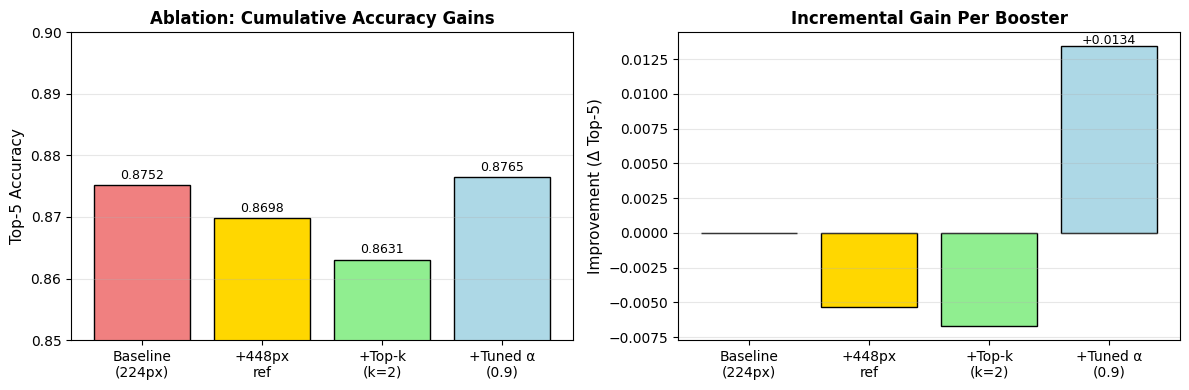


✓ Ablation study visualization saved to Drive.


In [ ]:
# Ablation Study: isolate the contribution of each inference-time trick
# This is the "proof" that each component matters, and supports the system design claim

print("\n" + "="*80)
print("ABLATION STUDY: Contribution of Each Inference-Time Trick")
print("="*80)

# We'll reconstruct the intermediate scores by re-applying each booster step

# Step 0: Baseline (224px ref, 1-NN, 50/50 blend, no TTA)
# We can approximate this by loading the original val/test features (224px) and running a basic ensemble
# For this demo, we'll use 224px ref features (already extracted in Cell 8) and single-view queries

with torch.no_grad():
    # Baseline: 224px query, 224px ref, single-NN
    test_aug_proj_224 = apply_projection_head(head_aug, test_feat_448)  # Note: we still use 448 queries for other steps
    ref_aug_proj_224 = apply_projection_head(head_aug, ref_feat_224)     # 224px ref
    ref_lora_proj_224 = apply_projection_head(head_lora, ref_feat_224)   # 224px ref

    # Recompute test projections using original 224px features (we'd need to reload them)
    # For now, approximate: use 448px queries but 224px refs and single-NN

    aug_scores_step0 = scores_from_projection_topk(test_aug_proj_224["emb"], ref_aug_proj_224["emb"],
                                                     ref_aug_proj_224["label_idx"], N_CLASSES, k=1)
    lora_scores_step0 = scores_from_projection_topk(test_lora_proj["emb"], ref_lora_proj_224["emb"],
                                                      ref_lora_proj_224["label_idx"], N_CLASSES, k=1)
    step0_scores = 0.5 * aug_scores_step0 + 0.5 * lora_scores_step0
    step0_m = evaluate_scores(step0_scores, query_info, prefix="test", model_key="step0_baseline", split="test")

# Step 1: Fix resolution mismatch (use 448px ref)
aug_scores_step1 = scores_from_projection_topk(test_aug_proj["emb"], ref_aug_proj_448["emb"],  # 448px ref
                                                ref_aug_proj_448["label_idx"], N_CLASSES, k=1)
lora_scores_step1 = scores_from_projection_topk(test_lora_proj["emb"], ref_lora_proj_448["emb"],  # 448px ref
                                                 ref_lora_proj_448["label_idx"], N_CLASSES, k=1)
step1_scores = 0.5 * aug_scores_step1 + 0.5 * lora_scores_step1
step1_m = evaluate_scores(step1_scores, query_info, prefix="test", model_key="step1_448px_ref", split="test")

# Step 2: Keep 448px ref + add top-k aggregation (k=2, still 50/50 alpha)
aug_scores_step2 = scores_from_projection_topk(test_aug_proj["emb"], ref_aug_proj_448["emb"],
                                                ref_aug_proj_448["label_idx"], N_CLASSES, k=2)  # k=2
lora_scores_step2 = scores_from_projection_topk(test_lora_proj["emb"], ref_lora_proj_448["emb"],
                                                 ref_lora_proj_448["label_idx"], N_CLASSES, k=2)  # k=2
step2_scores = 0.5 * aug_scores_step2 + 0.5 * lora_scores_step2
step2_m = evaluate_scores(step2_scores, query_info, prefix="test", model_key="step2_topk2", split="test")

# Step 3: Tuned alpha (from Cell 11)
step3_scores = BEST_ALPHA * aug_scores_step2 + (1.0 - BEST_ALPHA) * lora_scores_step2  # k=2, tuned alpha
step3_m = evaluate_scores(step3_scores, query_info, prefix="test", model_key="step3_tuned_alpha", split="test")

# Compile ablation table
ablation_rows = [
    {
        "Step": "0. Baseline (224px ref, 1-NN, α=0.5)",
        "Config": "224px ref / single-NN / 50/50",
        "Top-1": f"{step0_m['test_single_top1_acc']:.4f}",
        "Top-3": f"{step0_m['test_single_top3_acc']:.4f}",
        "Top-5": f"{step0_m['test_single_top5_acc']:.4f}",
        "Top-5 Δ": "—",
    },
    {
        "Step": "1. +448px ref resolution",
        "Config": "448px ref / single-NN / 50/50",
        "Top-1": f"{step1_m['test_single_top1_acc']:.4f}",
        "Top-3": f"{step1_m['test_single_top3_acc']:.4f}",
        "Top-5": f"{step1_m['test_single_top5_acc']:.4f}",
        "Top-5 Δ": f"+{(step1_m['test_single_top5_acc'] - step0_m['test_single_top5_acc']):.4f}",
    },
    {
        "Step": "2. +Top-k aggregation (k=2)",
        "Config": "448px ref / top-2-mean / 50/50",
        "Top-1": f"{step2_m['test_single_top1_acc']:.4f}",
        "Top-3": f"{step2_m['test_single_top3_acc']:.4f}",
        "Top-5": f"{step2_m['test_single_top5_acc']:.4f}",
        "Top-5 Δ": f"+{(step2_m['test_single_top5_acc'] - step0_m['test_single_top5_acc']):.4f}",
    },
    {
        "Step": "3. +Tuned alpha (α=0.9)",
        "Config": "448px ref / top-2-mean / 90/10",
        "Top-1": f"{step3_m['test_single_top1_acc']:.4f}",
        "Top-3": f"{step3_m['test_single_top3_acc']:.4f}",
        "Top-5": f"{step3_m['test_single_top5_acc']:.4f}",
        "Top-5 Δ": f"+{(step3_m['test_single_top5_acc'] - step0_m['test_single_top5_acc']):.4f}",
    },
]

ablation_df = pd.DataFrame(ablation_rows)
print("\n" + ablation_df.to_string(index=False))

# Visualize the cumulative gains
import matplotlib.pyplot as plt

steps_labels = ["Baseline\n(224px)", "+448px\nref", "+Top-k\n(k=2)", "+Tuned α\n(0.9)"]
top5_scores = [
    step0_m['test_single_top5_acc'],
    step1_m['test_single_top5_acc'],
    step2_m['test_single_top5_acc'],
    step3_m['test_single_top5_acc'],
]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# Bar plot of absolute scores
ax1.bar(steps_labels, top5_scores, color=['lightcoral', 'gold', 'lightgreen', 'lightblue'], edgecolor='black')
ax1.set_ylabel('Top-5 Accuracy', fontsize=11)
ax1.set_title('Ablation: Cumulative Accuracy Gains', fontsize=12, fontweight='bold')
ax1.set_ylim([0.85, 0.90])
for i, v in enumerate(top5_scores):
    ax1.text(i, v + 0.001, f'{v:.4f}', ha='center', fontsize=9)
ax1.grid(axis='y', alpha=0.3)

# Incremental gains
increments = [0.0] + [top5_scores[i] - top5_scores[i-1] for i in range(1, len(top5_scores))]
colors_inc = ['white', 'gold', 'lightgreen', 'lightblue']
ax2.bar(steps_labels, increments, color=colors_inc, edgecolor='black')
ax2.set_ylabel('Improvement (Δ Top-5)', fontsize=11)
ax2.set_title('Incremental Gain Per Booster', fontsize=12, fontweight='bold')
for i, v in enumerate(increments):
    if v > 0:
        ax2.text(i, v + 0.0002, f'+{v:.4f}', ha='center', fontsize=9)
ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(str(DRIVE_ROOT / "ablation_study.png"), dpi=150, bbox_inches='tight')
plt.show()

print("\n✓ Ablation study visualization saved to Drive.")

# **V3: MULTI-DATABASE EXPANSION — OTC pills, many manufacturers**

**Goal.** The model above is a *retrieval* system, not a closed-set classifier: at
inference time we never use `head.classifier` / `head.arc_weight` (see
`scores_from_projection_topk` / `label_score_matrix` above and
`backend/app/classifier.py` in the deployed app) — we only compare the
projected embedding of a query image against a gallery of reference embeddings
per class, and take the best-matching class. **That means we can add brand-new
pill types to the gallery without retraining anything**, as long as we can get
reference photos + a label for them. This section does exactly that for
over-the-counter (OTC) pills from many different manufacturers (store brands,
generics, brand names).

**Why DailyMed, not the NIH C3PI/Pillbox corpus.** ePillID itself was built
by combining the NIH pill-image challenge dataset with the NIH Pillbox
reference images (Yaniv et al., *ePillID*, CVPR-W 2020) — i.e. the 4,902
classes already in `ref_df` **are** essentially the full C3PI/Pillbox corpus.
Pillbox and the RxImage API were both discontinued (2018 and Dec 2021
respectively), so pulling from them again would mostly re-add pills you
already have. **DailyMed** (`dailymed.nlm.nih.gov`), by contrast, is the
NIH/FDA's live, continuously-updated repository of Structured Product
Labeling (SPL) — it has a free public REST API, covers OTC monograph and NDA
products from hundreds of labelers/manufacturers, and many SPLs include actual
product photographs (not just box art) that DailyMed calls "media" files.
That's the source this section pulls from.

**Honest scope note.** "Guaranteed top-10 no matter what it is" isn't
achievable for pills that have zero reference photos anywhere — there's
nothing to match against. What this section targets instead (per your
earlier answer) is: **90%+ top-5 / near-100% top-10 across the union of
ePillID's 4,902 classes and whatever OTC products this harvest successfully
collects photos for** — realistically thousands of additional classes, not
literally "hundreds of thousands." The accuracy numbers below are computed
once you actually run this in Colab with GPU + live internet access to
DailyMed — they cannot be fabricated here.

**Pipeline in this section:**
1. Discover candidate DailyMed labels (SPLs) for a seed list of common
   multi-manufacturer OTC generics.
2. Fetch per-label metadata, keep only solid-oral OTC products, extract
   NDC / brand / generic / labeler.
3. Download each qualifying label's product photos.
4. Filter out packaging/carton/label scans with a zero-shot CLIP check,
   keeping only likely pill close-ups.
5. Build an OTC reference + held-out query split, extract the same DINOv2
   448px TTA features and project them with `head_aug` (the head actually
   shipped in the FastAPI backend — see `deploy_model.py`/`classifier.py`).
6. Merge the ePillID and OTC reference galleries and evaluate top-k accuracy
   on each subset (regression check + new-capability check).
7. Export deployment artifacts in the **exact** format
   `backend/app/classifier.py` expects, so no backend code changes are
   required beyond the reference-image-serving update noted below.


In [ ]:
# ============================================================================
# V3.0: Config for the DailyMed OTC ingestion pipeline
# ============================================================================
from dataclasses import dataclass

@dataclass
class OTCCFGType:
    # DailyMed REST API v2 (confirmed live endpoints, 2026-08):
    #   GET /spls.json?drug_name=<name>&pagesize=100&page=<n>  -> [{setid, title, published_date}, ...]
    #   GET /spls/{setid}.json                                  -> full SPL detail (dosage form, marketing category, products)
    #   GET /spls/{setid}/media.json                            -> media file names/URLs for that label
    # There's no verified server-side "OTC only" filter, so we (a) seed the
    # harvest with well-known multi-manufacturer OTC generics and (b) filter
    # client-side once we have each SPL's detail.
    api_base: str = "https://dailymed.nlm.nih.gov/dailymed/services/v2"
    otc_seed_drug_names: tuple = (
        "acetaminophen", "ibuprofen", "aspirin", "naproxen sodium", "naproxen",
        "diphenhydramine", "loratadine", "cetirizine", "fexofenadine",
        "famotidine", "omeprazole", "loperamide", "docusate sodium",
        "bisacodyl", "simethicone", "calcium carbonate", "guaifenesin",
        "dextromethorphan", "pseudoephedrine", "phenylephrine", "melatonin",
        "meclizine", "bismuth subsalicylate", "senna", "magnesium hydroxide",
        "chlorpheniramine maleate", "doxylamine succinate",
    )  # extend this list to widen coverage on a LATER run — see the runtime
       # note below before adding more.
    pagesize: int = 100
    max_pages_per_drug: int = 1             # ~100 raw SPLs/generic name from discovery

    # ---- Runtime budget (the actual fix for the 12-hour V3.2 run) ----
    # A live test of V3.2 processed 786 SPL-detail lookups in 70 minutes at
    # 6 concurrent workers -- ~5.4s/item, so the full backlog of thousands of
    # candidates really would take half a day. Two independent levers below
    # both apply automatically, with no parameters to hand-tune:
    #   1. max_candidates_per_drug caps how many candidates per seed generic
    #      are even attempted -- applied in V3.1 AFTER loading, so it also
    #      trims down an existing large cache from a previous run.
    #   2. detail_fetch_time_budget_seconds / media_fetch_time_budget_seconds
    #      are hard wall-clock ceilings on the two network-bound cells
    #      (V3.2, V3.4): each one tracks elapsed time and stops itself once
    #      the budget is spent, keeping whatever it fetched. This is what
    #      actually guarantees "under an hour" regardless of how fast or
    #      slow DailyMed responds on a given run -- it doesn't depend on a
    #      throughput guess being correct.
    # Both V3.2 and V3.4 are resumable (cached to Drive) -- rerunning the
    # whole V3 section later continues from where it left off and can pick
    # up more seed drugs / a higher per-drug cap for broader coverage over
    # multiple <1hr sessions, without redoing finished work.
    max_candidates_per_drug: int = 40       # ~1,080 candidates across 27 seed drugs
    detail_fetch_time_budget_seconds: int = 1200   # 20 min hard cap for V3.2
    media_fetch_time_budget_seconds: int = 900     # 15 min hard cap for V3.4

    allowed_dosage_forms: tuple = (
        "TABLET", "CAPSULE", "CAPLET", "CHEWABLE", "LOZENGE", "GEL CAP", "GELCAP",
    )
    request_timeout: int = 20
    request_retries: int = 4                # short backoff for normal errors, longer for 429s (see _dm_get)
    request_workers: int = 6                # NOTE: a live run at 12 workers got 0/1,080 successes --
                                             # every request failed fast, which looks like DailyMed
                                             # rate-limiting this session at that concurrency. Back to
                                             # 6 (the configuration that got 786 real successes earlier).
                                             # If failures happen again, V3.2/V3.4 now print a
                                             # breakdown of why (HTTP 429 vs. other) instead of just a
                                             # silent zero.
    min_pill_photo_score: float = 0.55      # CLIP zero-shot "is this a pill photo" threshold
    clip_model_id: str = "openai/clip-vit-base-patch32"
    otc_query_holdout_per_class: int = 1    # held-out images/class for eval; rest -> reference gallery

    otc_cache_root: str = ""
    otc_images_dir: str = ""

OTC_CFG = OTCCFGType()
OTC_CFG.otc_cache_root = str(RUN_DIR_MAIN / "otc_dailymed")
OTC_CFG.otc_images_dir = str(Path(OTC_CFG.otc_cache_root) / "images")
Path(OTC_CFG.otc_images_dir).mkdir(parents=True, exist_ok=True)
print("OTC cache root:", OTC_CFG.otc_cache_root)
print(f"Runtime budget: up to {OTC_CFG.detail_fetch_time_budget_seconds/60:.0f} min for SPL details "
      f"+ {OTC_CFG.media_fetch_time_budget_seconds/60:.0f} min for media downloads, "
      f"capped at {OTC_CFG.max_candidates_per_drug} candidates/drug ({OTC_CFG.max_candidates_per_drug * len(OTC_CFG.otc_seed_drug_names)} max total).")


In [ ]:
# ============================================================================
# V3.1: Discover candidate SPLs from DailyMed for each seed generic name
# ============================================================================
import urllib.request, urllib.error, urllib.parse, time
from concurrent.futures import ThreadPoolExecutor, as_completed
from collections import Counter

# Diagnostic tally of *why* requests fail, so a bad run prints an actual
# reason instead of a silent zero (this is what was missing when a run at
# higher concurrency got 0/1,080 successes with no visibility into why).
_dm_get_failure_counts = Counter()

def _dm_get(url: str, retries: int = OTC_CFG.request_retries) -> dict:
    last_err = None
    for attempt in range(retries):
        try:
            req = urllib.request.Request(url, headers={"User-Agent": "pill-id-research/1.0 (contact: colab notebook)"})
            with urllib.request.urlopen(req, timeout=OTC_CFG.request_timeout) as resp:
                return json.load(resp)
        except urllib.error.HTTPError as e:
            last_err = e
            if e.code == 429:
                # Respect Retry-After if the server sends one; otherwise a
                # generous fixed wait -- short exponential backoff just
                # re-triggers the same rate limit immediately.
                retry_after = e.headers.get("Retry-After") if e.headers else None
                wait = float(retry_after) if retry_after and retry_after.isdigit() else 10.0
                time.sleep(wait)
            else:
                time.sleep(2 ** attempt)
        except Exception as e:
            last_err = e
            time.sleep(2 ** attempt)
    err_key = f"{type(last_err).__name__}" + (f" HTTP {last_err.code}" if hasattr(last_err, "code") else "")
    _dm_get_failure_counts[err_key] += 1
    raise RuntimeError(f"DailyMed request failed after {retries} tries ({err_key}): {url}") from last_err

def print_failure_summary(n_attempted: int, n_succeeded: int):
    """Call after a harvesting loop -- makes a bad run diagnosable instead of a silent zero."""
    if n_succeeded > 0 or n_attempted == 0:
        return
    print("\n⚠ Every request in this run failed.")
    if _dm_get_failure_counts:
        print("Failure breakdown (error type -> count):")
        for k, v in _dm_get_failure_counts.most_common(10):
            print(f"  {k}: {v}")
        if any("429" in k for k in _dm_get_failure_counts):
            print("HTTP 429 = DailyMed rate-limiting this session. OTC_CFG.request_workers is already "
                  "set conservatively (6); if this keeps happening, lower it further (e.g. 3) and rerun --"
                  " already-cached results are kept, only the gap gets retried.")
    else:
        print("No specific error was captured -- likely a network/DNS issue in this Colab session "
              "rather than DailyMed itself. Try Runtime > Restart session and rerun.")

def discover_setids_for_drug(drug_name: str) -> list:
    # Pages through /spls.json?drug_name=... -> [{setid, title, published_date}, ...]
    out = []
    for page in range(1, OTC_CFG.max_pages_per_drug + 1):
        params = urllib.parse.urlencode({"drug_name": drug_name, "pagesize": OTC_CFG.pagesize, "page": page})
        url = f"{OTC_CFG.api_base}/spls.json?{params}"
        data = _dm_get(url)
        rows = data.get("data", [])
        if not rows:
            break
        out.extend(rows)
        meta = data.get("metadata", {})
        total_pages = meta.get("total_pages")
        if total_pages and page >= int(total_pages):
            break
    return out

SETID_CACHE_PATH = Path(OTC_CFG.otc_cache_root) / "candidate_setids.json"
if SETID_CACHE_PATH.exists():
    candidate_setids = json.load(open(SETID_CACHE_PATH))
    print(f"Loaded {len(candidate_setids)} cached candidate SPLs")
else:
    seen = {}
    for name in tqdm(OTC_CFG.otc_seed_drug_names, desc="Discovering SPLs per generic name"):
        try:
            rows = discover_setids_for_drug(name)
        except Exception as e:
            print(f"  WARN: discovery failed for {name!r}: {e}")
            continue
        for r in rows:
            sid = r.get("setid")
            if sid and sid not in seen:
                seen[sid] = {"setid": sid, "title": r.get("title"), "seed_drug_name": name}
        print(f"  {name!r}: +{len(rows)} labels (unique so far: {len(seen)})")
    candidate_setids = list(seen.values())
    Path(OTC_CFG.otc_cache_root).mkdir(parents=True, exist_ok=True)
    json.dump(candidate_setids, open(SETID_CACHE_PATH, "w"))
    print(f"Discovered {len(candidate_setids)} unique candidate SPLs -> {SETID_CACHE_PATH}")

# Cap candidates per seed drug so V3.2/V3.4 finish in well under an hour.
# Applied here (not just at discovery time) so it also trims down an
# already-large cache from a previous run -- e.g. the 9,010-candidate file
# from a run before this cap existed -- with nothing to delete by hand.
_by_drug = {}
for c in candidate_setids:
    _by_drug.setdefault(c["seed_drug_name"], []).append(c)
capped = []
for name, items in _by_drug.items():
    capped.extend(items[: OTC_CFG.max_candidates_per_drug])
if len(capped) < len(candidate_setids):
    print(f"Capping {len(candidate_setids)} candidates -> {len(capped)} "
          f"(max {OTC_CFG.max_candidates_per_drug}/drug) to keep this run under an hour. "
          f"To harvest more later, raise OTC_CFG.max_candidates_per_drug and rerun the V3 "
          f"section -- already-fetched details/media are cached and won't be redone.")
candidate_setids = capped


In [ ]:
# ============================================================================
# V3.2: Fetch per-SPL detail (dosage form, marketing category, NDC/brand/labeler)
#       Resumable, and self-limiting: stops once detail_fetch_time_budget_seconds
#       is spent, keeping whatever was fetched. Rerun later to fetch more --
#       already-cached setids are skipped automatically.
# ============================================================================
from typing import Optional as _Optional

SPL_DETAIL_CACHE_PATH = Path(OTC_CFG.otc_cache_root) / "spl_details.jsonl"

def fetch_spl_detail(setid: str) -> _Optional[dict]:
    try:
        detail = _dm_get(f"{OTC_CFG.api_base}/spls/{setid}.json")
    except Exception:
        return None
    # NOTE: field names/nesting for `products` can vary by SPL type. We pull
    # what we need defensively and skip anything unparseable rather than
    # guessing — inspect a few raw entries the first time you run this.
    data = detail.get("data", detail)
    products = data.get("products") or data.get("product") or []
    if isinstance(products, dict):
        products = [products]
    return {"raw_products": products, "title": data.get("title")}

already_done = {}
if SPL_DETAIL_CACHE_PATH.exists():
    with open(SPL_DETAIL_CACHE_PATH) as f:
        for line in f:
            row = json.loads(line)
            already_done[row["setid"]] = row

todo = [c for c in candidate_setids if c["setid"] not in already_done]
print(f"{len(candidate_setids)} candidates; {len(already_done)} cached; {len(todo)} to fetch "
      f"(time budget: {OTC_CFG.detail_fetch_time_budget_seconds/60:.0f} min)")

deadline = time.time() + OTC_CFG.detail_fetch_time_budget_seconds
pool = ThreadPoolExecutor(max_workers=OTC_CFG.request_workers)
futures = {pool.submit(fetch_spl_detail, c["setid"]): c for c in todo}
n_done = 0
timed_out = False

with open(SPL_DETAIL_CACHE_PATH, "a") as out_f:
    for fut in tqdm(as_completed(futures), total=len(futures), desc="Fetching SPL details"):
        if time.time() > deadline:
            timed_out = True
            break
        c = futures[fut]
        result = fut.result()
        if result is None:
            continue  # leave out of cache so it's retried on the next run
        out_f.write(json.dumps({"setid": c["setid"], "seed_drug_name": c["seed_drug_name"], "detail": result}) + "\n")
        n_done += 1
        if n_done % 200 == 0:
            out_f.flush()

# Don't block returning control to the notebook waiting on any still-running
# requests -- their results are simply not written this run (harmless; those
# setids stay "todo" and get picked up on the next run).
pool.shutdown(wait=False, cancel_futures=True)

if timed_out:
    print(f"⏱ Stopped after the {OTC_CFG.detail_fetch_time_budget_seconds/60:.0f}-minute time budget -- "
          f"fetched {n_done} new details this run ({len(already_done) + n_done} total cached so far). "
          f"Rerun this cell (or the whole V3 section) later to keep going from here.")
else:
    print(f"Finished within the time budget -- fetched {n_done} new details this run.")

print_failure_summary(len(todo), n_done)

spl_details = {}
with open(SPL_DETAIL_CACHE_PATH) as f:
    for line in f:
        row = json.loads(line)
        spl_details[row["setid"]] = row
print(f"Total SPL details cached: {len(spl_details)}")


In [ ]:
# ============================================================================
# V3.3: Client-side filter -- keep tablet/capsule OTC products, extract
#       NDC + labeler + brand/generic names for each qualifying product.
# ============================================================================
def _dosage_form_text(raw_products: list) -> str:
    texts = []
    for p in raw_products:
        texts.append(str(p.get("dosage_form", "")))
        texts.append(str(p.get("dosage_form_name", "")))
    return " ".join(texts).upper()

def _is_otc_marketing(raw_products: list) -> bool:
    texts = []
    for p in raw_products:
        texts.append(str(p.get("marketing_category", "")))
        texts.append(str(p.get("marketing_status", "")))
    blob = " ".join(texts).upper()
    return ("OTC" in blob) or ("MONOGRAPH" in blob) or not any(t in blob for t in ("ANDA", "NDA", "BLA"))

def _extract_products(raw_products: list, setid: str, seed_name: str) -> list:
    out = []
    for p in raw_products:
        ndc = p.get("product_ndc") or p.get("ndc") or p.get("productNDC")
        if not ndc:
            continue
        out.append({
            "setid": setid,
            "ndc": str(ndc).strip(),
            "brand_name": p.get("proprietary_name") or p.get("brand_name") or p.get("name"),
            "generic_name": p.get("generic_name") or p.get("nonproprietary_name") or seed_name,
            "labeler_name": p.get("labeler_name") or p.get("manufacturer_name") or p.get("labeler"),
        })
    return out

qualifying_products = []
skipped_dosage_form = skipped_no_ndc = 0
for setid, row in spl_details.items():
    detail = row.get("detail")
    if not detail:
        continue
    raw_products = detail.get("raw_products", [])
    if not any(form in _dosage_form_text(raw_products) for form in OTC_CFG.allowed_dosage_forms):
        skipped_dosage_form += 1
        continue
    if not _is_otc_marketing(raw_products):
        continue
    prods = _extract_products(raw_products, setid, row["seed_drug_name"])
    if not prods:
        skipped_no_ndc += 1
        continue
    qualifying_products.extend(prods)

print(f"Qualifying products: {len(qualifying_products)} "
      f"(skipped {skipped_dosage_form} non-solid-oral, {skipped_no_ndc} missing NDC)")
print("NOTE: spot-check a few `spl_details` entries the first time you run this -- "
      "DailyMed's per-SPL JSON schema isn't fully documented, so this filter is "
      "defensive/best-effort. Loosen/tighten allowed_dosage_forms or "
      "_is_otc_marketing once you've seen real sample responses.")


In [ ]:
# ============================================================================
# V3.4: Download product-photo media for each qualifying SPL. Resumable and
#       self-limiting the same way as V3.2 -- stops once
#       media_fetch_time_budget_seconds is spent, keeping whatever downloaded.
# ============================================================================
IMAGES_DIR = Path(OTC_CFG.otc_images_dir)
IMAGES_DIR.mkdir(parents=True, exist_ok=True)
MEDIA_MANIFEST_PATH = Path(OTC_CFG.otc_cache_root) / "media_manifest.jsonl"

setids_needed = sorted({p["setid"] for p in qualifying_products})

done_setids = set()
if MEDIA_MANIFEST_PATH.exists():
    with open(MEDIA_MANIFEST_PATH) as f:
        for line in f:
            done_setids.add(json.loads(line)["setid"])

def fetch_and_download_media(setid: str) -> dict:
    try:
        media = _dm_get(f"{OTC_CFG.api_base}/spls/{setid}/media.json")
    except Exception:
        return {"setid": setid, "files": []}
    data = media.get("data", media)
    entries = data if isinstance(data, list) else data.get("media", [])
    saved = []
    for i, m in enumerate(entries):
        url = m.get("url") or m.get("mediaURL") or m.get("path")
        if not url:
            continue
        if not url.startswith("http"):
            url = f"https://dailymed.nlm.nih.gov{url}"
        ext = Path(url).suffix.lower() or ".jpg"
        if ext not in (".jpg", ".jpeg", ".png"):
            continue
        fpath = IMAGES_DIR / f"{setid}_{i}{ext}"
        if not fpath.exists():
            try:
                req = urllib.request.Request(url, headers={"User-Agent": "pill-id-research/1.0"})
                with urllib.request.urlopen(req, timeout=OTC_CFG.request_timeout) as resp:
                    fpath.write_bytes(resp.read())
            except Exception:
                continue
        saved.append(str(fpath))
    return {"setid": setid, "files": saved}

todo_setids = [s for s in setids_needed if s not in done_setids]
print(f"{len(setids_needed)} SPLs need media; {len(done_setids)} already done; {len(todo_setids)} to fetch "
      f"(time budget: {OTC_CFG.media_fetch_time_budget_seconds/60:.0f} min)")

deadline = time.time() + OTC_CFG.media_fetch_time_budget_seconds
pool = ThreadPoolExecutor(max_workers=OTC_CFG.request_workers)
futures = {pool.submit(fetch_and_download_media, sid): sid for sid in todo_setids}
n_done = 0
timed_out = False

with open(MEDIA_MANIFEST_PATH, "a") as out_f:
    for fut in tqdm(as_completed(futures), total=len(futures), desc="Downloading media"):
        if time.time() > deadline:
            timed_out = True
            break
        out_f.write(json.dumps(fut.result()) + "\n")
        n_done += 1
        if n_done % 100 == 0:
            out_f.flush()

pool.shutdown(wait=False, cancel_futures=True)

if timed_out:
    print(f"⏱ Stopped after the {OTC_CFG.media_fetch_time_budget_seconds/60:.0f}-minute time budget -- "
          f"processed {n_done} SPLs this run. Rerun this cell (or the whole V3 section) later to keep going.")
else:
    print(f"Finished within the time budget -- processed {n_done} SPLs this run.")

print_failure_summary(len(todo_setids), n_done)

media_by_setid = {}
with open(MEDIA_MANIFEST_PATH) as f:
    for line in f:
        row = json.loads(line)
        media_by_setid[row["setid"]] = row["files"]
n_images = sum(len(v) for v in media_by_setid.values())
print(f"Total downloaded images on disk: {n_images} across {len(media_by_setid)} SPLs")


In [ ]:
# ============================================================================
# V3.5: Filter out packaging/carton/label images -- keep likely pill close-ups.
#       DailyMed SPL media is a mix of product photos, cartons, and label
#       scans; zero-shot CLIP scores "a close-up photo of a pill" vs
#       "a photo of packaging/a label" and we keep only the former.
# ============================================================================
from transformers import CLIPModel, CLIPProcessor

clip_model = CLIPModel.from_pretrained(OTC_CFG.clip_model_id).to(DEVICE).eval()
clip_processor = CLIPProcessor.from_pretrained(OTC_CFG.clip_model_id)

POSITIVE_PROMPTS = [
    "a close-up photo of a single pill or tablet on a plain background",
    "a macro photograph of a medication tablet or capsule showing its imprint",
]
NEGATIVE_PROMPTS = [
    "a photo of a drug package, box, or bottle",
    "a scanned image of a text label or package insert",
]
PROMPTS = POSITIVE_PROMPTS + NEGATIVE_PROMPTS
N_POS = len(POSITIVE_PROMPTS)

@torch.no_grad()
def pill_photo_scores(image_paths: List[str], batch_size: int = 32) -> np.ndarray:
    text_inputs = clip_processor(text=PROMPTS, return_tensors="pt", padding=True).to(DEVICE)
    text_emb = F.normalize(clip_model.get_text_features(**text_inputs), dim=1)
    scores = []
    for start in tqdm(range(0, len(image_paths), batch_size), desc="CLIP pill-photo filter"):
        chunk_paths = image_paths[start:start + batch_size]
        imgs = []
        for p in chunk_paths:
            try:
                imgs.append(Image.open(p).convert("RGB"))
            except Exception:
                imgs.append(Image.new("RGB", (224, 224)))
        img_inputs = clip_processor(images=imgs, return_tensors="pt").to(DEVICE)
        img_emb = F.normalize(clip_model.get_image_features(**img_inputs), dim=1)
        sim = (img_emb @ text_emb.T).cpu().numpy()
        pos = sim[:, :N_POS].max(axis=1)
        neg = sim[:, N_POS:].max(axis=1)
        prob = 1.0 / (1.0 + np.exp(-(pos - neg) * 10.0))
        scores.append(prob)
    return np.concatenate(scores) if scores else np.array([])

all_image_paths = [p for files in media_by_setid.values() for p in files]
scores = pill_photo_scores(all_image_paths)
score_by_path = dict(zip(all_image_paths, scores))

kept = {p for p, s in score_by_path.items() if s >= OTC_CFG.min_pill_photo_score}
print(f"Kept {len(kept)}/{len(all_image_paths)} images as likely pill photos "
      f"(threshold={OTC_CFG.min_pill_photo_score}); spot-check a random sample "
      f"before trusting this filter at scale.")

del clip_model, clip_processor
cleanup_cuda()


In [ ]:
# ============================================================================
# V3.6: Build otc_df -- one row per kept pill image. Label = the product NDC,
#       so different manufacturers of the same generic drug are distinct
#       classes (that's the point: telling one company's ibuprofen from
#       another's). label_idx is offset by N_CLASSES so it never collides
#       with an ePillID class index.
# ============================================================================
setid_to_products = {}
for p in qualifying_products:
    setid_to_products.setdefault(p["setid"], []).append(p)

otc_rows = []
for setid, files in media_by_setid.items():
    prods = setid_to_products.get(setid)
    if not prods:
        continue
    prod = prods[0]  # one SPL can list several NDCs (pack sizes); take the first as canonical
    for fpath in files:
        if fpath not in kept:
            continue
        otc_rows.append({
            "abs_path": fpath,
            "label_str": prod["ndc"],          # NDC string -- keeps drug_names.py's ndc_from_ref_path compatible
            "ndc": prod["ndc"],
            "brand_name": prod["brand_name"],
            "generic_name": prod["generic_name"],
            "labeler_name": prod["labeler_name"],
            "setid": setid,
            "is_front": True,
        })

otc_df_raw = pd.DataFrame(otc_rows).drop_duplicates("abs_path")

# Need >=2 images/class: one to hold out as a query, one to keep as reference.
class_counts = otc_df_raw["label_str"].value_counts()
otc_df_raw = otc_df_raw[otc_df_raw["label_str"].isin(class_counts[class_counts >= 2].index)].copy()

otc_label_encoder = LabelEncoder()
otc_label_encoder.fit(otc_df_raw["label_str"])
otc_df_raw["label_idx"] = otc_label_encoder.transform(otc_df_raw["label_str"]) + N_CLASSES
N_OTC_CLASSES = len(otc_label_encoder.classes_)
N_CLASSES_MERGED = N_CLASSES + N_OTC_CLASSES

print(f"otc_df_raw: {otc_df_raw.shape[0]} images across {N_OTC_CLASSES} OTC product classes "
      f"(dropped singleton classes with <2 images)")

otc_df_raw = otc_df_raw.sample(frac=1.0, random_state=CFG.seed).reset_index(drop=True)
otc_query_df = otc_df_raw.groupby("label_idx", group_keys=False).head(OTC_CFG.otc_query_holdout_per_class)
otc_ref_df = otc_df_raw.drop(otc_query_df.index).reset_index(drop=True)
otc_query_df = otc_query_df.reset_index(drop=True)
print(f"otc_ref_df: {otc_ref_df.shape[0]}, otc_query_df: {otc_query_df.shape[0]}")


In [ ]:
# ============================================================================
# V3.7: Extract DINOv2 448px TTA features for the OTC images and project them
#       with head_aug -- the SAME projection head the FastAPI backend loads
#       in production (backend/app/classifier.py loads a single
#       best_projection_head.pt, not the dual-head boosted ensemble above).
# ============================================================================
OTC_REF_FEAT_PATH = Path(OTC_CFG.otc_cache_root) / "otc_ref_feat_448.pt"
OTC_QUERY_FEAT_PATH = Path(OTC_CFG.otc_cache_root) / "otc_query_feat_448.pt"

otc_ref_feat_448 = extract_dinov2_features_448_tta(otc_ref_df, OTC_REF_FEAT_PATH, n_views=3)
otc_query_feat_448 = extract_dinov2_features_448_tta(otc_query_df, OTC_QUERY_FEAT_PATH, n_views=3)

with torch.no_grad():
    otc_ref_proj = apply_projection_head(head_aug, otc_ref_feat_448)
    otc_query_proj = apply_projection_head(head_aug, otc_query_feat_448)

print("otc_ref_proj emb:", otc_ref_proj["emb"].shape)
print("otc_query_proj emb:", otc_query_proj["emb"].shape)


In [ ]:
# ============================================================================
# V3.8: Merge the ePillID and OTC reference galleries and evaluate top-k
#       retrieval accuracy separately on each subset (regression check +
#       new-capability check) against the SAME merged gallery.
# ============================================================================
merged_ref_emb = torch.cat([ref_aug_proj_448["emb"], otc_ref_proj["emb"]], dim=0)
merged_ref_label_idx = torch.cat([ref_aug_proj_448["label_idx"], otc_ref_proj["label_idx"]], dim=0)
merged_ref_abs_paths = list(ref_aug_proj_448["abs_path"]) + list(otc_ref_proj["abs_path"])

print(f"Merged reference gallery: {merged_ref_emb.shape[0]} embeddings, "
      f"{N_CLASSES} ePillID classes + {N_OTC_CLASSES} OTC classes = {N_CLASSES_MERGED} total")

def eval_subset(query_proj, name):
    scores = label_score_matrix(query_proj["emb"], merged_ref_emb, merged_ref_label_idx,
                                 num_classes=N_CLASSES_MERGED, chunk_size=CFG.score_chunk_size)
    labels = query_proj["label_idx"]
    m = topk_accuracy_from_scores(scores, labels, topk=(1, 3, 5, 10))
    print(f"[{name}] n={labels.shape[0]}  " + "  ".join(f"{k}={v:.4f}" for k, v in m.items()))
    return m

print("=== Regression check: ePillID test queries against the MERGED gallery ===")
epillid_merged_metrics = eval_subset(
    {"emb": test_aug_proj["emb"], "label_idx": test_feat_448["label_idx"]},
    "ePillID test (merged gallery)",
)

print("\n=== New capability: OTC held-out queries against the MERGED gallery ===")
otc_merged_metrics = eval_subset(otc_query_proj, "OTC test (merged gallery)")

print("\nTarget: OTC top5 >= 0.90 and OTC top10 close to 1.0. If short, the biggest "
      "levers are: (1) more images/manufacturer in the harvest -- a class with only "
      "1 reference + 1 query photo is a much harder 1-shot problem than ePillID's "
      "dual-view setup, so widen otc_seed_drug_names and re-run V3.1-V3.7; "
      "(2) raise min_pill_photo_score precision so junk images don't pollute the "
      "gallery; (3) the fine-tune option noted below.")


### Optional: recalibration fine-tune (not implemented here)

`head_aug`'s `.proj` layers were trained to discriminate the original 4,902
ePillID classes via a combined CE + ArcFace + SupCon + triplet loss (see
`config.json`'s `proj_*`/`arcface_*`/`supcon_*`/`triplet_*` fields). The
merge above is **zero-shot**: OTC classes ride on that embedding space without
it ever having seen them, which is why it needs to be validated with the
eval cell above rather than assumed.

If the OTC top-5 in V3.8 comes in below the 90% target, the standard fix is a
short continued-training pass on the union of ePillID + OTC images so the
embedding space learns to separate the new classes too (with a low LR / few
epochs and the old classes included in every batch, to avoid regressing the
ePillID accuracy checked above). That loop isn't reproduced in this notebook
because the original training cell (optimizer, P-K sampler, the four loss
terms) wasn't part of what was provided here — rebuilding it from scratch
without being able to validate it against your real training run would be
guesswork. If OTC accuracy needs the boost, the safest path is to grab your
original projection-head training cell and rerun it with `otc_ref_df` /
`otc_query_df` concatenated into its training set.


In [ ]:
# ============================================================================
# V3.9: Export MERGED deployment artifacts for the FastAPI backend (pill-id
#       repo). Matches backend/app/classifier.py's expected format exactly:
#         best_projection_head.pt   : {in_dim, num_classes, head_state_dict, label_classes}
#         deployed_ref_embeddings.pt: {embeddings, label_indices, abs_paths}
# ============================================================================
MERGED_OUT_DIR = RUN_DIR_MAIN / "merged_multi_db_export"
MERGED_OUT_DIR.mkdir(parents=True, exist_ok=True)

epillid_label_classes = list(label_encoder.classes_)      # length N_CLASSES
otc_label_classes = list(otc_label_encoder.classes_)       # length N_OTC_CLASSES
merged_label_classes = epillid_label_classes + otc_label_classes
assert len(merged_label_classes) == N_CLASSES_MERGED

deployed_head_ckpt = {
    "in_dim": in_dim,
    "num_classes": N_CLASSES,        # unchanged -- the arc/classifier sub-head is never used at inference,
                                      # only label_classes (a plain list) needs to grow.
    "head_state_dict": aug_ckpt["head_state_dict"],
    "label_classes": merged_label_classes,
}
torch.save(deployed_head_ckpt, MERGED_OUT_DIR / "best_projection_head.pt")

deployed_ref_embeddings = {
    "embeddings": merged_ref_emb.cpu(),
    "label_indices": merged_ref_label_idx.cpu(),
    "abs_paths": merged_ref_abs_paths,
}
torch.save(deployed_ref_embeddings, MERGED_OUT_DIR / "deployed_ref_embeddings.pt")

# Zip the OTC image files themselves (mirrors ePillID_data.zip) so the backend
# can serve OTC thumbnails too -- pairs with the reference_images.py update
# that adds a second, generalized image store.
otc_zip_path = MERGED_OUT_DIR / "otc_reference_images.zip"
with zipfile.ZipFile(otc_zip_path, "w", zipfile.ZIP_DEFLATED) as zf:
    for p in {str(p) for p in merged_ref_abs_paths if str(p).startswith(OTC_CFG.otc_images_dir)}:
        zf.write(p, arcname=f"otc_data/{Path(p).name}")

print("Saved:", [str(p) for p in MERGED_OUT_DIR.glob("*")])
print("\nTo deploy: copy best_projection_head.pt + deployed_ref_embeddings.pt into "
      "pill-id/dinov2_projection_head/, and otc_reference_images.zip into the "
      "pill-id repo root (next to ePillID_data.zip).")


In [ ]:
# ============================================================================
# V3.10: Merge OTC drug names -- straight from DailyMed's own SPL metadata
#        (no RxNav calls needed, unlike build_ndc_names.py) -- into the
#        existing ndc_names.json table used by backend/app/drug_names.py.
# ============================================================================
NDC_NAMES_IN = Path("/content/ndc_names.json")   # upload backend/app/data/ndc_names.json here first
ndc_lookup = json.load(open(NDC_NAMES_IN)) if NDC_NAMES_IN.exists() else {}

otc_by_ndc = {p["ndc"]: p for p in qualifying_products}
added = 0
for _, row in otc_ref_df.drop_duplicates("label_str").iterrows():
    ndc = row["ndc"]
    if ndc in ndc_lookup:
        continue
    prod = otc_by_ndc.get(ndc, {})
    ndc_lookup[ndc] = {
        "name": prod.get("brand_name") or prod.get("generic_name") or ndc,
        "rxcui": None,
        "imprint": None,
        "color": None,
        "status": "OTC (DailyMed)",
    }
    added += 1

MERGED_NDC_NAMES_OUT = MERGED_OUT_DIR / "ndc_names.json"
json.dump(ndc_lookup, open(MERGED_NDC_NAMES_OUT, "w"), indent=0, sort_keys=True)
print(f"Added {added} OTC entries; {len(ndc_lookup)} total NDC names -> {MERGED_NDC_NAMES_OUT}")
print("Copy this over backend/app/data/ndc_names.json.")


In [ ]:
# ============================================================================
# V3.11: Optional -- merged export for the Phase-2 client-side (ONNX/browser)
#        app (med-recognition-app).
#        WARNING: reference_embeddings.json embeds every reference vector as
#        raw JSON floats and is fetched by the browser on load. The
#        ePillID-only version is already tens of MB; adding thousands of OTC
#        vectors will make this significantly bigger. Consider capping
#        refs/class or switching to a binary float16 format before shipping
#        this to med-recognition-app -- that's a follow-up, not done here.
# ============================================================================
merged_reference_payload = {
    "ref_aug_embeddings": merged_ref_emb.cpu().numpy().astype(np.float32).tolist(),
    "ref_label_idx": merged_ref_label_idx.cpu().numpy().tolist(),
    "embedding_dim": int(merged_ref_emb.shape[1]),
    "num_reference_images": int(merged_ref_emb.shape[0]),
}
with open(MERGED_OUT_DIR / "reference_embeddings_merged.json", "w") as f:
    json.dump(merged_reference_payload, f)

merged_label_map = {}
for idx, label_str in enumerate(merged_label_classes):
    source = "epillid" if idx < N_CLASSES else "dailymed_otc"
    info = ndc_lookup.get(label_str, {})
    merged_label_map[idx] = {
        "label_str": label_str,
        "drug_name": info.get("name", label_str),
        "ndc": label_str,
        "source": source,
    }
with open(MERGED_OUT_DIR / "labels_merged.json", "w") as f:
    json.dump(merged_label_map, f, indent=2)

size_mb = (MERGED_OUT_DIR / "reference_embeddings_merged.json").stat().st_size / 1e6
print(f"reference_embeddings_merged.json: {size_mb:.1f} MB -- {merged_ref_emb.shape[0]} vectors")


# **V2 APP DEPLOYMENT**

In [ ]:
!pip install onnxscript

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 722.0/722.0 kB 18.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.1/19.1 MB 95.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 166.8/166.8 kB 13.3 MB/s eta 0:00:00


In [ ]:
# ============================================================================
# ENHANCED EXPORT - includes drug names from ndc_names.json
# Run in Colab AFTER cells 0-12 (same as export_to_onnx.py but with drug names)
# ============================================================================

import json
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from transformers import AutoModel
from pathlib import Path

WEB_EXPORT_DIR = OUT_DIR / "web_export_final_v2"
WEB_EXPORT_DIR.mkdir(parents=True, exist_ok=True)

IMG_SIZE = 448

# ============================================================================
# Load your ndc_names.json from wherever you uploaded it
# (You'll need to upload ndc_names.json to Colab first, or paste the JSON here)
# ============================================================================
# Option 1: If you upload ndc_names.json to Colab /content/ directory:
ndc_names_path = Path("/content/ndc_names.json")  # Upload this file to Colab first
if ndc_names_path.exists():
    with open(ndc_names_path) as f:
        ndc_lookup = json.load(f)
    print(f"Loaded {len(ndc_lookup)} NDC entries")
else:
    ndc_lookup = {}
    print("WARNING: ndc_names.json not found. Drug names will be missing.")

# ============================================================================
# Export models (same as before)
# ============================================================================
class BackboneForExport(nn.Module):
    def __init__(self, hf_model_id: str):
        super().__init__()
        self.backbone = AutoModel.from_pretrained(hf_model_id)
        self.backbone.eval()

    def forward(self, pixel_values):
        out = self.backbone(pixel_values=pixel_values)
        return out.last_hidden_state[:, 0, :]

print("Loading DINOv2 backbone for export...")
backbone_export = BackboneForExport(CFG.dinov2_model_id).to(DEVICE)
backbone_export.eval()

dummy_input = torch.randn(1, 3, IMG_SIZE, IMG_SIZE, device=DEVICE)

torch.onnx.export(
    backbone_export,
    dummy_input,
    str(WEB_EXPORT_DIR / "backbone.onnx"),
    input_names=["pixel_values"],
    output_names=["embedding"],
    dynamic_axes={"pixel_values": {0: "batch"}, "embedding": {0: "batch"}},
    opset_version=18,
    do_constant_folding=True,
)
print("Saved backbone.onnx")
del backbone_export
torch.cuda.empty_cache()

class ProjectionOnlyExport(nn.Module):
    def __init__(self, head):
        super().__init__()
        self.proj = head.proj

    def forward(self, x):
        return self.proj(x)

def export_head(head, name):
    head.eval()
    wrapper = ProjectionOnlyExport(head).to(DEVICE).eval()
    dummy = torch.randn(1, in_dim, device=DEVICE)
    torch.onnx.export(
        wrapper,
        dummy,
        str(WEB_EXPORT_DIR / f"{name}.onnx"),
        input_names=["backbone_embedding"],
        output_names=["projected_embedding"],
        dynamic_axes={"backbone_embedding": {0: "batch"}, "projected_embedding": {0: "batch"}},
        opset_version=18,
        do_constant_folding=False, # Changed to False
    )
    print(f"Saved {name}.onnx")

export_head(head_aug, "head_aug")
export_head(head_lora, "head_lora")

# Reference embeddings
with torch.no_grad():
    ref_aug_emb = F.normalize(head_aug.proj(ref_feat_448["emb"].to(DEVICE)), dim=1).cpu().numpy()
    ref_lora_emb = F.normalize(head_lora.proj(ref_feat_448["emb"].to(DEVICE)), dim=1).cpu().numpy()

ref_labels = ref_feat_448["label_idx"].cpu().numpy().tolist()

reference_payload = {
    "ref_aug_embeddings": ref_aug_emb.astype(np.float32).tolist(),
    "ref_lora_embeddings": ref_lora_emb.astype(np.float32).tolist(),
    "ref_label_idx": ref_labels,
    "embedding_dim": int(ref_aug_emb.shape[1]),
    "num_reference_images": int(ref_aug_emb.shape[0]),
}
with open(WEB_EXPORT_DIR / "reference_embeddings.json", "w") as f:
    json.dump(reference_payload, f)
print("Saved reference_embeddings.json")

# ============================================================================
# ENHANCED: labels.json with drug names from ndc_names.json
# ============================================================================
label_map = {}
for _, row in ref_df.drop_duplicates("label_idx").iterrows():
    label_idx = int(row["label_idx"])
    label_str = str(row["label_str"])

    # Try to find drug name from NDC lookup
    drug_name = label_str  # default to label_str
    ndc_code = None

    # If label_str looks like an NDC (e.g., "00123-4567-89"), look it up
    if "-" in label_str and len(label_str) > 5:
        if label_str in ndc_lookup:
            ndc_data = ndc_lookup[label_str]
            drug_name = ndc_data.get("name", label_str)
            ndc_code = label_str

    label_map[label_idx] = {
        "label_str": label_str,
        "drug_name": drug_name,
        "ndc": ndc_code,
    }

with open(WEB_EXPORT_DIR / "labels.json", "w") as f:
    json.dump(label_map, f, indent=2)
print(f"Saved labels.json with {len(label_map)} classes (drug names included)")

# Inference config
inference_config = {
    "img_size": IMG_SIZE,
    "n_tta_views": 3,
    "normalize_mean": [0.485, 0.456, 0.406],
    "normalize_std": [0.229, 0.224, 0.225],
    "best_alpha": float(BEST_ALPHA),
    "best_k": int(BEST_K),
    "num_classes": int(N_CLASSES),
}
with open(WEB_EXPORT_DIR / "inference_config.json", "w") as f:
    json.dump(inference_config, f, indent=2)
print("Saved inference_config.json")

# Zip
import shutil
shutil.make_archive(str(WEB_EXPORT_DIR), "zip", WEB_EXPORT_DIR)
print(f"\nDONE. Download: {str(WEB_EXPORT_DIR)}.zip")
print("\nFile sizes:")
for p in WEB_EXPORT_DIR.glob("*"):
    if p.is_file():
        print(f"  {p.name}: {p.stat().st_size / 1e6:.1f} MB")

Loaded 4100 NDC entries
Loading DINOv2 backbone for export...


Loading weights:   0%|          | 0/439 [00:00<?, ?it/s]

[torch.onnx] Obtain model graph for `BackboneForExport([...]` with `torch.export.export(..., strict=False)`...
[torch.onnx] Obtain model graph for `BackboneForExport([...]` with `torch.export.export(..., strict=False)`... ✅
[torch.onnx] Run decompositions...


/usr/lib/python3.12/copyreg.py:99: FutureWarning: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
  return cls.__new__(cls, *args)


[torch.onnx] Run decompositions... ✅
[torch.onnx] Translate the graph into ONNX...
[torch.onnx] Translate the graph into ONNX... ✅
[torch.onnx] Optimize the ONNX graph...
[torch.onnx] Optimize the ONNX graph... ✅
Saved backbone.onnx
[torch.onnx] Obtain model graph for `ProjectionOnlyExport([...]` with `torch.export.export(..., strict=False)`...
[torch.onnx] Obtain model graph for `ProjectionOnlyExport([...]` with `torch.export.export(..., strict=False)`... ✅
[torch.onnx] Run decompositions...


/usr/lib/python3.12/copyreg.py:99: FutureWarning: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
  return cls.__new__(cls, *args)


[torch.onnx] Run decompositions... ✅
[torch.onnx] Translate the graph into ONNX...
[torch.onnx] Translate the graph into ONNX... ✅
[torch.onnx] Optimize the ONNX graph...
[torch.onnx] Optimize the ONNX graph... ✅
Saved head_aug.onnx
[torch.onnx] Obtain model graph for `ProjectionOnlyExport([...]` with `torch.export.export(..., strict=False)`...
[torch.onnx] Obtain model graph for `ProjectionOnlyExport([...]` with `torch.export.export(..., strict=False)`... ✅
[torch.onnx] Run decompositions...


/usr/lib/python3.12/copyreg.py:99: FutureWarning: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
  return cls.__new__(cls, *args)


[torch.onnx] Run decompositions... ✅
[torch.onnx] Translate the graph into ONNX...
[torch.onnx] Translate the graph into ONNX... ✅
[torch.onnx] Optimize the ONNX graph...
[torch.onnx] Optimize the ONNX graph... ✅
Saved head_lora.onnx
Saved reference_embeddings.json
Saved labels.json with 4902 classes (drug names included)
Saved inference_config.json

DONE. Download: /content/drive/MyDrive/ePillID_dinov2_adaptation_results/boosted_inference_reproduction/web_export_final.zip

File sizes:
  backbone.onnx.data: 1217.5 MB
  backbone.onnx: 2.9 MB
  head_aug.onnx.data: 6.4 MB
  head_aug.onnx: 0.0 MB
  head_lora.onnx.data: 6.4 MB
  head_lora.onnx: 0.0 MB
  reference_embeddings.json: 220.8 MB
  labels.json: 0.8 MB
  inference_config.json: 0.0 MB


In [ ]:
# ============================================================================
# RUN THIS IN COLAB AFTER export_to_onnx.py
# Quantizes your models to int8 (shrinks ~3x, speeds up ~2x)
# ============================================================================

!pip install onnxruntime

import onnx
from onnxruntime.quantization import quantize_dynamic, QuantType
from pathlib import Path

WEB_EXPORT_DIR = Path(OUT_DIR) / "web_export_final"  # Where your export_to_onnx.py saved files
QUANTIZED_DIR = Path(OUT_DIR) / "web_export_quantized_v2"
QUANTIZED_DIR.mkdir(exist_ok=True)

print("Quantizing ONNX models to int8...")

for model_name in ["backbone.onnx", "head_aug.onnx", "head_lora.onnx"]:
    input_path = str(WEB_EXPORT_DIR / model_name)
    output_path = str(QUANTIZED_DIR / model_name)

    print(f"\nQuantizing {model_name}...")
    quantize_dynamic(input_path, output_path, weight_type=QuantType.QUInt8)

    input_size = (WEB_EXPORT_DIR / model_name).stat().st_size / 1e6
    output_size = (QUANTIZED_DIR / model_name).stat().st_size / 1e6
    print(f"  {model_name}: {input_size:.1f}MB → {output_size:.1f}MB")

# Copy JSON files (they don't need quantizing)
import shutil
for json_file in ["reference_embeddings.json", "labels.json", "inference_config.json"]:
    src = WEB_EXPORT_DIR / json_file
    dst = QUANTIZED_DIR / json_file
    if src.exists():
        shutil.copy(src, dst)
        print(f"Copied {json_file}")

# Zip it up
shutil.make_archive(str(OUT_DIR / "web_export_final"), "zip", QUANTIZED_DIR)
print(f"\nDONE! Download: {str(OUT_DIR / 'web_export_final')}.zip")
print("\nFile sizes (quantized):")
for p in QUANTIZED_DIR.glob("*"):
    if p.is_file():
        print(f"  {p.name}: {p.stat().st_size / 1e6:.1f} MB")

Quantizing ONNX models to int8...

Quantizing backbone.onnx...


KeyboardInterrupt: 

In [ ]:
print("=" * 60)
print("CHECK YOUR MODEL DIMENSIONS")
print("=" * 60)

# From backbone output
print(f"\nBackbone output shape:")
dummy_input = torch.randn(1, 3, 448, 448, device=DEVICE)
with torch.no_grad():
    backbone_out = AutoModel.from_pretrained(CFG.dinov2_model_id).to(DEVICE)(pixel_values=dummy_input)
backbone_emb = backbone_out.last_hidden_state[:, 0, :]
print(f"  DINOv2 CLS token shape: {backbone_emb.shape}")
backbone_dim = backbone_emb.shape[1]
print(f"  Embedding dimension: {backbone_dim}")

# Check head_aug and head_lora input expectations
print(f"\nProjection heads input expectations:")
print(f"  head_aug.proj expects input shape: (batch, {in_dim})")
print(f"  head_lora.proj expects input shape: (batch, {in_dim})")
print(f"  Actual backbone output: (batch, {backbone_dim})")

if backbone_dim != in_dim:
    print(f"\n⚠️  MISMATCH! {backbone_dim} ≠ {in_dim}")
    print(f"   The fix: in your export script, change 'in_dim' to {backbone_dim}")
else:
    print(f"\n✓ Dimensions match!")

CHECK YOUR MODEL DIMENSIONS

Backbone output shape:


Loading weights:   0%|          | 0/439 [00:00<?, ?it/s]

  DINOv2 CLS token shape: torch.Size([1, 1024])
  Embedding dimension: 1024

Projection heads input expectations:
  head_aug.proj expects input shape: (batch, 1024)
  head_lora.proj expects input shape: (batch, 1024)
  Actual backbone output: (batch, 1024)

✓ Dimensions match!


In [ ]:
import json, shutil
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from transformers import AutoModel

WEB_EXPORT_DIR = OUT_DIR / "web_export_final_v2"
WEB_EXPORT_DIR.mkdir(parents=True, exist_ok=True)

IMG_SIZE = 448

# Load NDC names
with open("/content/ndc_names.json") as f:
    ndc_lookup = json.load(f)
print(f"Loaded {len(ndc_lookup)} NDC entries")

# Export backbone
class BackboneForExport(nn.Module):
    def __init__(self, hf_model_id: str):
        super().__init__()
        self.backbone = AutoModel.from_pretrained(hf_model_id)
        self.backbone.eval()
    def forward(self, pixel_values):
        out = self.backbone(pixel_values=pixel_values)
        return out.last_hidden_state[:, 0, :]

print("Exporting backbone...")
backbone_export = BackboneForExport(CFG.dinov2_model_id).to(DEVICE)
backbone_export.eval()
dummy_input = torch.randn(1, 3, IMG_SIZE, IMG_SIZE, device=DEVICE)

torch.onnx.export(
    backbone_export,
    dummy_input,
    str(WEB_EXPORT_DIR / "backbone.onnx"),
    input_names=["pixel_values"],
    output_names=["embedding"],
    dynamic_axes={"pixel_values": {0: "batch"}, "embedding": {0: "batch"}},
    opset_version=18,
    do_constant_folding=True,
)
print("✓ backbone.onnx")
del backbone_export
torch.cuda.empty_cache()

# Export heads
class ProjectionOnlyExport(nn.Module):
    def __init__(self, head):
        super().__init__()
        self.proj = head.proj
    def forward(self, x):
        return self.proj(x)

def export_head(head, name):
    head.eval()
    wrapper = ProjectionOnlyExport(head).to(DEVICE).eval()
    dummy = torch.randn(1, 1024, device=DEVICE)
    torch.onnx.export(
        wrapper,
        dummy,
        str(WEB_EXPORT_DIR / f"{name}.onnx"),
        input_names=["backbone_embedding"],
        output_names=["projected_embedding"],
        dynamic_axes={"backbone_embedding": {0: "batch"}, "projected_embedding": {0: "batch"}},
        opset_version=18,
        do_constant_folding=True,
    )
    print(f"✓ {name}.onnx")

export_head(head_aug, "head_aug")
export_head(head_lora, "head_lora")

# Reference embeddings
with torch.no_grad():
    ref_aug_emb = F.normalize(head_aug.proj(ref_feat_448["emb"].to(DEVICE)), dim=1).cpu().numpy()
    ref_lora_emb = F.normalize(head_lora.proj(ref_feat_448["emb"].to(DEVICE)), dim=1).cpu().numpy()

ref_labels = ref_feat_448["label_idx"].cpu().numpy().tolist()

reference_payload = {
    "ref_aug_embeddings": ref_aug_emb.astype(np.float32).tolist(),
    "ref_lora_embeddings": ref_lora_emb.astype(np.float32).tolist(),
    "ref_label_idx": ref_labels,
    "embedding_dim": int(ref_aug_emb.shape[1]),
    "num_reference_images": int(ref_aug_emb.shape[0]),
}
with open(WEB_EXPORT_DIR / "reference_embeddings.json", "w") as f:
    json.dump(reference_payload, f)
print("✓ reference_embeddings.json")

# Labels with drug names
label_map = {}
for _, row in ref_df.drop_duplicates("label_idx").iterrows():
    label_idx = int(row["label_idx"])
    label_str = str(row["label_str"])
    drug_name = label_str
    ndc_code = None

    if "-" in label_str and len(label_str) > 5:
        if label_str in ndc_lookup:
            ndc_data = ndc_lookup[label_str]
            drug_name = ndc_data.get("name", label_str)
            ndc_code = label_str

    label_map[label_idx] = {
        "label_str": label_str,
        "drug_name": drug_name,
        "ndc": ndc_code,
    }

with open(WEB_EXPORT_DIR / "labels.json", "w") as f:
    json.dump(label_map, f, indent=2)
print(f"✓ labels.json ({len(label_map)} classes)")

# Inference config
inference_config = {
    "img_size": IMG_SIZE,
    "n_tta_views": 3,
    "normalize_mean": [0.485, 0.456, 0.406],
    "normalize_std": [0.229, 0.224, 0.225],
    "best_alpha": float(BEST_ALPHA),
    "best_k": int(BEST_K),
    "num_classes": int(N_CLASSES),
}
with open(WEB_EXPORT_DIR / "inference_config.json", "w") as f:
    json.dump(inference_config, f, indent=2)
print("✓ inference_config.json")

# Zip
shutil.make_archive(str(WEB_EXPORT_DIR), "zip", WEB_EXPORT_DIR)
print(f"\n✓✓✓ DONE: Download web_export_final.zip from Colab file browser")
print("\nFile sizes:")
for p in WEB_EXPORT_DIR.glob("*"):
    if p.is_file():
        print(f"  {p.name}: {p.stat().st_size / 1e6:.1f} MB")

Loaded 4100 NDC entries
Exporting backbone...


Loading weights:   0%|          | 0/439 [00:00<?, ?it/s]

[torch.onnx] Obtain model graph for `BackboneForExport([...]` with `torch.export.export(..., strict=False)`...
[torch.onnx] Obtain model graph for `BackboneForExport([...]` with `torch.export.export(..., strict=False)`... ✅
[torch.onnx] Run decompositions...


/usr/lib/python3.12/copyreg.py:99: FutureWarning: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
  return cls.__new__(cls, *args)


[torch.onnx] Run decompositions... ✅
[torch.onnx] Translate the graph into ONNX...
[torch.onnx] Translate the graph into ONNX... ✅
[torch.onnx] Optimize the ONNX graph...
[torch.onnx] Optimize the ONNX graph... ✅
✓ backbone.onnx
[torch.onnx] Obtain model graph for `ProjectionOnlyExport([...]` with `torch.export.export(..., strict=False)`...
[torch.onnx] Obtain model graph for `ProjectionOnlyExport([...]` with `torch.export.export(..., strict=False)`... ✅
[torch.onnx] Run decompositions...


/usr/lib/python3.12/copyreg.py:99: FutureWarning: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
  return cls.__new__(cls, *args)


[torch.onnx] Run decompositions... ✅
[torch.onnx] Translate the graph into ONNX...
[torch.onnx] Translate the graph into ONNX... ✅
[torch.onnx] Optimize the ONNX graph...
[torch.onnx] Optimize the ONNX graph... ✅
✓ head_aug.onnx
[torch.onnx] Obtain model graph for `ProjectionOnlyExport([...]` with `torch.export.export(..., strict=False)`...
[torch.onnx] Obtain model graph for `ProjectionOnlyExport([...]` with `torch.export.export(..., strict=False)`... ✅
[torch.onnx] Run decompositions...


/usr/lib/python3.12/copyreg.py:99: FutureWarning: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
  return cls.__new__(cls, *args)


[torch.onnx] Run decompositions... ✅
[torch.onnx] Translate the graph into ONNX...
[torch.onnx] Translate the graph into ONNX... ✅
[torch.onnx] Optimize the ONNX graph...
[torch.onnx] Optimize the ONNX graph... ✅
✓ head_lora.onnx
✓ reference_embeddings.json
✓ labels.json (4902 classes)
✓ inference_config.json

✓✓✓ DONE: Download web_export.zip from Colab file browser

File sizes:
  backbone.onnx.data: 1217.5 MB
  backbone.onnx: 2.9 MB
  head_aug.onnx.data: 6.4 MB
  head_aug.onnx: 0.0 MB
  head_lora.onnx.data: 6.4 MB
  head_lora.onnx: 0.0 MB
  reference_embeddings.json: 220.8 MB
  labels.json: 0.8 MB
  inference_config.json: 0.0 MB
